In [62]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sweetviz as sv
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report, roc_auc_score
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import cross_val_score
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import optuna
from sklearn.inspection import permutation_importance
from sklearn.feature_selection import SelectKBest, mutual_info_classif
import shap
from sklearn.model_selection import cross_val_predict

In [35]:
spotify_high_pop = pd.read_csv("/Users/donyabehroozi/Documents/gsb545/GSB-545/Project Files/high_popularity_spotify_data.csv")
spotify_high_pop.head()

,energy,tempo,danceability,playlist_genre,loudness,liveness,valence,track_artist,time_signature,speechiness,...,instrumentalness,track_album_id,mode,key,duration_ms,acousticness,id,playlist_subgenre,type,playlist_id
0,0.592,157.969,0.521,pop,-7.777,0.122,0.535,"Lady Gaga, Bruno Mars",3,0.0304,...,0.0000,10FLjwfpbxLmW8c25Xyc2N,0,6,251668,0.3080,2plbrEY59IikOBgBGLjaoe,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M
1,0.507,104.978,0.747,pop,-10.171,0.117,0.438,Billie Eilish,4,0.0358,...,0.0608,7aJuG4TFXa2hmE4z1yxc3n,1,2,210373,0.2000,6dOtVTDdiauQNBQEDOtlAB,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M
2,0.808,108.548,0.554,pop,-4.169,0.159,0.372,Gracie Abrams,4,0.0368,...,0.0000,0hBRqPYPXhr1RkTDG3n4Mk,1,1,166300,0.2140,7ne4VBA60CxGM75vw0EYad,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M
3,0.910,112.966,0.670,pop,-4.070,0.304,0.786,Sabrina Carpenter,4,0.0634,...,0.0000,4B4Elma4nNDUyl6D5PvQkj,0,0,157280,0.0939,1d7Ptw3qYcfpdLNL5REhtJ,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M
4,0.783,149.027,0.777,pop,-4.477,0.355,0.939,"ROSÉ, Bruno Mars",4,0.2600,...,0.0000,2IYQwwgxgOIn7t3iF6ufFD,0,0,169917,0.0283,5vNRhkKd0yEAg8suGBpjeY,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M


In [36]:
spotify_low_pop = pd.read_csv('/Users/donyabehroozi/Documents/gsb545/GSB-545/Project Files/low_popularity_spotify_data.csv')
spotify_low_pop.head()

,time_signature,track_popularity,speechiness,danceability,playlist_name,track_artist,duration_ms,energy,playlist_genre,playlist_subgenre,...,track_album_id,playlist_id,track_id,valence,key,tempo,loudness,acousticness,liveness,track_album_name
0,4.0,23,0.0393,0.636,Rock Classics,Creedence Clearwater Revival,138053.0,0.746,rock,classic,...,4A8gFwqd9jTtnsNwUu3OQx,37i9dQZF1DWXRqgorJj26U,5e6x5YRnMJIKvYpZxLqdpH,0.432,0.0,132.310,-3.785,0.0648,0.1730,The Long Road Home - The Ultimate John Fogerty...
1,4.0,53,0.0317,0.572,Rock Classics,Van Halen,241600.0,0.835,rock,classic,...,2c965LEDRNrXXCeBOAAwns,37i9dQZF1DWXRqgorJj26U,5FqYA8KfiwsQvyBI4IamnY,0.795,0.0,129.981,-6.219,0.1710,0.0702,The Collection
2,4.0,55,0.0454,0.591,Rock Classics,Stevie Nicks,329413.0,0.804,rock,classic,...,3S404OgKoVQSJ3xXrDVlp8,37i9dQZF1DWXRqgorJj26U,5LNiqEqpDc8TuqPy79kDBu,0.658,0.0,111.457,-7.299,0.3270,0.0818,Bella Donna (Deluxe Edition)
3,4.0,64,0.1010,0.443,Jazz Classics,"Ella Fitzgerald, Louis Armstrong",185160.0,0.104,jazz,classic,...,1y5KGkUKO0NG32MhIIagCA,37i9dQZF1DXbITWG1ZJKYt,78MI7mu1LV1k4IA2HzKmHe,0.394,0.0,76.474,-17.042,0.9130,0.1910,"Love, Ella"
4,4.0,62,0.0298,0.685,Jazz Classics,Galt MacDermot,205720.0,0.472,jazz,classic,...,6f4b9wVTkKAf096k4XG6x5,37i9dQZF1DXbITWG1ZJKYt,6MN6yRVriszuyAVlyF8ndB,0.475,9.0,80.487,-9.691,0.7850,0.2240,Shapes of Rhythm/Woman Is Sweeter


In [37]:
#make binary popular variable (1 = popular track, 0 = not a popular track)
spotify_high_pop["popular"] = 1
spotify_high_pop.head()

,energy,tempo,danceability,playlist_genre,loudness,liveness,valence,track_artist,time_signature,speechiness,...,track_album_id,mode,key,duration_ms,acousticness,id,playlist_subgenre,type,playlist_id,popular
0,0.592,157.969,0.521,pop,-7.777,0.122,0.535,"Lady Gaga, Bruno Mars",3,0.0304,...,10FLjwfpbxLmW8c25Xyc2N,0,6,251668,0.3080,2plbrEY59IikOBgBGLjaoe,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M,1
1,0.507,104.978,0.747,pop,-10.171,0.117,0.438,Billie Eilish,4,0.0358,...,7aJuG4TFXa2hmE4z1yxc3n,1,2,210373,0.2000,6dOtVTDdiauQNBQEDOtlAB,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M,1
2,0.808,108.548,0.554,pop,-4.169,0.159,0.372,Gracie Abrams,4,0.0368,...,0hBRqPYPXhr1RkTDG3n4Mk,1,1,166300,0.2140,7ne4VBA60CxGM75vw0EYad,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M,1
3,0.910,112.966,0.670,pop,-4.070,0.304,0.786,Sabrina Carpenter,4,0.0634,...,4B4Elma4nNDUyl6D5PvQkj,0,0,157280,0.0939,1d7Ptw3qYcfpdLNL5REhtJ,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M,1
4,0.783,149.027,0.777,pop,-4.477,0.355,0.939,"ROSÉ, Bruno Mars",4,0.2600,...,2IYQwwgxgOIn7t3iF6ufFD,0,0,169917,0.0283,5vNRhkKd0yEAg8suGBpjeY,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M,1


In [38]:
#make binary popular variable (1 = popular track, 0 = not a popular track)
spotify_low_pop["popular"] = 0
spotify_low_pop.head()

,time_signature,track_popularity,speechiness,danceability,playlist_name,track_artist,duration_ms,energy,playlist_genre,playlist_subgenre,...,playlist_id,track_id,valence,key,tempo,loudness,acousticness,liveness,track_album_name,popular
0,4.0,23,0.0393,0.636,Rock Classics,Creedence Clearwater Revival,138053.0,0.746,rock,classic,...,37i9dQZF1DWXRqgorJj26U,5e6x5YRnMJIKvYpZxLqdpH,0.432,0.0,132.310,-3.785,0.0648,0.1730,The Long Road Home - The Ultimate John Fogerty...,0
1,4.0,53,0.0317,0.572,Rock Classics,Van Halen,241600.0,0.835,rock,classic,...,37i9dQZF1DWXRqgorJj26U,5FqYA8KfiwsQvyBI4IamnY,0.795,0.0,129.981,-6.219,0.1710,0.0702,The Collection,0
2,4.0,55,0.0454,0.591,Rock Classics,Stevie Nicks,329413.0,0.804,rock,classic,...,37i9dQZF1DWXRqgorJj26U,5LNiqEqpDc8TuqPy79kDBu,0.658,0.0,111.457,-7.299,0.3270,0.0818,Bella Donna (Deluxe Edition),0
3,4.0,64,0.1010,0.443,Jazz Classics,"Ella Fitzgerald, Louis Armstrong",185160.0,0.104,jazz,classic,...,37i9dQZF1DXbITWG1ZJKYt,78MI7mu1LV1k4IA2HzKmHe,0.394,0.0,76.474,-17.042,0.9130,0.1910,"Love, Ella",0
4,4.0,62,0.0298,0.685,Jazz Classics,Galt MacDermot,205720.0,0.472,jazz,classic,...,37i9dQZF1DXbITWG1ZJKYt,6MN6yRVriszuyAVlyF8ndB,0.475,9.0,80.487,-9.691,0.7850,0.2240,Shapes of Rhythm/Woman Is Sweeter,0


In [39]:
#concatenate high and low popularity datasets
spotify_full = pd.concat([spotify_high_pop, spotify_low_pop], axis=0).reset_index(drop=True)
spotify_full.head()

,energy,tempo,danceability,playlist_genre,loudness,liveness,valence,track_artist,time_signature,speechiness,...,track_album_id,mode,key,duration_ms,acousticness,id,playlist_subgenre,type,playlist_id,popular
0,0.592,157.969,0.521,pop,-7.777,0.122,0.535,"Lady Gaga, Bruno Mars",3.0,0.0304,...,10FLjwfpbxLmW8c25Xyc2N,0.0,6.0,251668.0,0.3080,2plbrEY59IikOBgBGLjaoe,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M,1
1,0.507,104.978,0.747,pop,-10.171,0.117,0.438,Billie Eilish,4.0,0.0358,...,7aJuG4TFXa2hmE4z1yxc3n,1.0,2.0,210373.0,0.2000,6dOtVTDdiauQNBQEDOtlAB,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M,1
2,0.808,108.548,0.554,pop,-4.169,0.159,0.372,Gracie Abrams,4.0,0.0368,...,0hBRqPYPXhr1RkTDG3n4Mk,1.0,1.0,166300.0,0.2140,7ne4VBA60CxGM75vw0EYad,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M,1
3,0.910,112.966,0.670,pop,-4.070,0.304,0.786,Sabrina Carpenter,4.0,0.0634,...,4B4Elma4nNDUyl6D5PvQkj,0.0,0.0,157280.0,0.0939,1d7Ptw3qYcfpdLNL5REhtJ,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M,1
4,0.783,149.027,0.777,pop,-4.477,0.355,0.939,"ROSÉ, Bruno Mars",4.0,0.2600,...,2IYQwwgxgOIn7t3iF6ufFD,0.0,0.0,169917.0,0.0283,5vNRhkKd0yEAg8suGBpjeY,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M,1


## EDA

In [30]:
#examine shape of data
spotify_full.shape

(4831, 30)

In [31]:
# check data types
spotify_full.dtypes

energy                      float64
tempo                       float64
danceability                float64
playlist_genre                  str
loudness                    float64
liveness                    float64
valence                     float64
track_artist                    str
time_signature              float64
speechiness                 float64
track_popularity              int64
track_href                      str
uri                             str
track_album_name                str
playlist_name                   str
analysis_url                    str
track_id                        str
track_name                      str
track_album_release_date        str
instrumentalness            float64
track_album_id                  str
mode                        float64
key                         float64
duration_ms                 float64
acousticness                float64
id                              str
playlist_subgenre               str
type                        

In [32]:
#check for missing values
spotify_full.isna().sum()

energy                      1
tempo                       1
danceability                1
playlist_genre              0
loudness                    1
liveness                    1
valence                     1
track_artist                0
time_signature              1
speechiness                 1
track_popularity            0
track_href                  1
uri                         1
track_album_name            1
playlist_name               0
analysis_url                1
track_id                    0
track_name                  0
track_album_release_date    0
instrumentalness            1
track_album_id              0
mode                        1
key                         1
duration_ms                 1
acousticness                1
id                          1
playlist_subgenre           0
type                        1
playlist_id                 0
popular                     0
dtype: int64

In [40]:
#drop NAs because there are so few
spotify_full = spotify_full.dropna()
spotify_full.isna().sum()

energy                      0
tempo                       0
danceability                0
playlist_genre              0
loudness                    0
liveness                    0
valence                     0
track_artist                0
time_signature              0
speechiness                 0
track_popularity            0
track_href                  0
uri                         0
track_album_name            0
playlist_name               0
analysis_url                0
track_id                    0
track_name                  0
track_album_release_date    0
instrumentalness            0
track_album_id              0
mode                        0
key                         0
duration_ms                 0
acousticness                0
id                          0
playlist_subgenre           0
type                        0
playlist_id                 0
popular                     0
dtype: int64

In [34]:
print(spotify_full.shape)

(4829, 30)


In [35]:
#check for duplicates
spotify_full.duplicated().sum()

np.int64(0)

In [41]:
# some data preprocessing

# extract release year from track_album_release_date
spotify_full['release_year'] = pd.to_datetime(
    spotify_full['track_album_release_date'], errors='coerce').dt.year

In [37]:
spotify_full.isna().sum()

energy                        0
tempo                         0
danceability                  0
playlist_genre                0
loudness                      0
liveness                      0
valence                       0
track_artist                  0
time_signature                0
speechiness                   0
track_popularity              0
track_href                    0
uri                           0
track_album_name              0
playlist_name                 0
analysis_url                  0
track_id                      0
track_name                    0
track_album_release_date      0
instrumentalness              0
track_album_id                0
mode                          0
key                           0
duration_ms                   0
acousticness                  0
id                            0
playlist_subgenre             0
type                          0
playlist_id                   0
popular                       0
release_year                138
dtype: i

In [42]:
# find rows where release_year is NaN (i.e. date couldn't be parsed)
mask = spotify_full['release_year'].isna()
print(spotify_full.loc[mask, 'track_album_release_date'].value_counts())

track_album_release_date
1998       10
1996        9
2005        8
2012        8
2010        7
1977        6
2000        6
2004        5
2001        5
1976        4
1982        4
1995        4
2003        4
2002        4
2006        4
1992        3
1983        3
2007        3
1999        3
1994        3
2014        3
2008        3
1997        3
1979        2
1986        2
1981        2
1985        2
1975        2
2015        2
1990        2
2011        2
1970        1
1973        1
1971        1
1984        1
1980        1
1979-06     1
1978        1
1972        1
2013        1
1991        1
Name: count, dtype: int64


In [43]:
#fix problematic release years
def parse_release_year(date_str):
    if pd.isna(date_str):
        return None
    date_str = str(date_str).strip()
    # handle year only (e.g. "1998") or year-month (e.g. "1979-06")
    try:
        return pd.to_datetime(date_str).year
    except:
        return None

spotify_full['release_year'] = spotify_full['track_album_release_date'].apply(parse_release_year)
print(spotify_full['release_year'].isna().sum())

0


In [44]:
# drop irrelevant columns
drop_cols = ['track_artist', 'track_href', 'uri', 'track_album_name', 
             'playlist_name', 'analysis_url', 'track_id', 'track_name',
             'track_album_id', 'id', 'type', 'playlist_id',
             'track_album_release_date',  # replaced by release_year
             'track_popularity']  # drops leaky variable

spotify_full = spotify_full.drop(columns=drop_cols)

In [12]:
#quantitative variables summary statistics
spotify_full.describe()

,energy,tempo,danceability,loudness,liveness,valence,time_signature,speechiness,instrumentalness,mode,key,duration_ms,acousticness,popular,release_year
count,4829.000000,4829.000000,4829.000000,4829.000000,4829.000000,4829.000000,4829.000000,4829.000000,4829.000000,4829.000000,4829.000000,4.829000e+03,4829.000000,4829.000000,4829.000000
mean,0.586621,118.271840,0.622299,-9.283028,0.167609,0.481851,3.936633,0.101747,0.201094,0.562228,5.233796,2.061598e+05,0.341279,0.348934,2016.760199
std,0.246240,28.515018,0.187723,7.129469,0.124442,0.258006,0.409753,0.101040,0.351943,0.496164,3.581084,8.175164e+04,0.325387,0.476682,10.729003
min,0.000202,48.232000,0.058900,-48.069000,0.021000,0.029600,1.000000,0.021900,0.000000,0.000000,0.000000,3.537500e+04,0.000004,0.000000,1954.000000
25%,0.442000,96.063000,0.525000,-10.298000,0.095400,0.275000,4.000000,0.038600,0.000000,0.000000,2.000000,1.590000e+05,0.053000,0.000000,2015.000000
50%,0.633000,118.068000,0.653000,-7.191000,0.118000,0.483000,4.000000,0.056100,0.000092,1.000000,5.000000,1.948800e+05,0.225000,0.000000,2022.000000
75%,0.777000,136.732000,0.758000,-5.339000,0.195000,0.690000,4.000000,0.118000,0.201000,1.000000,8.000000,2.334780e+05,0.590000,1.000000,2024.000000
max,0.998000,241.426000,0.979000,1.318000,0.979000,0.987000,5.000000,0.927000,0.991000,1.000000,11.000000,1.355260e+06,0.996000,1.000000,2024.000000


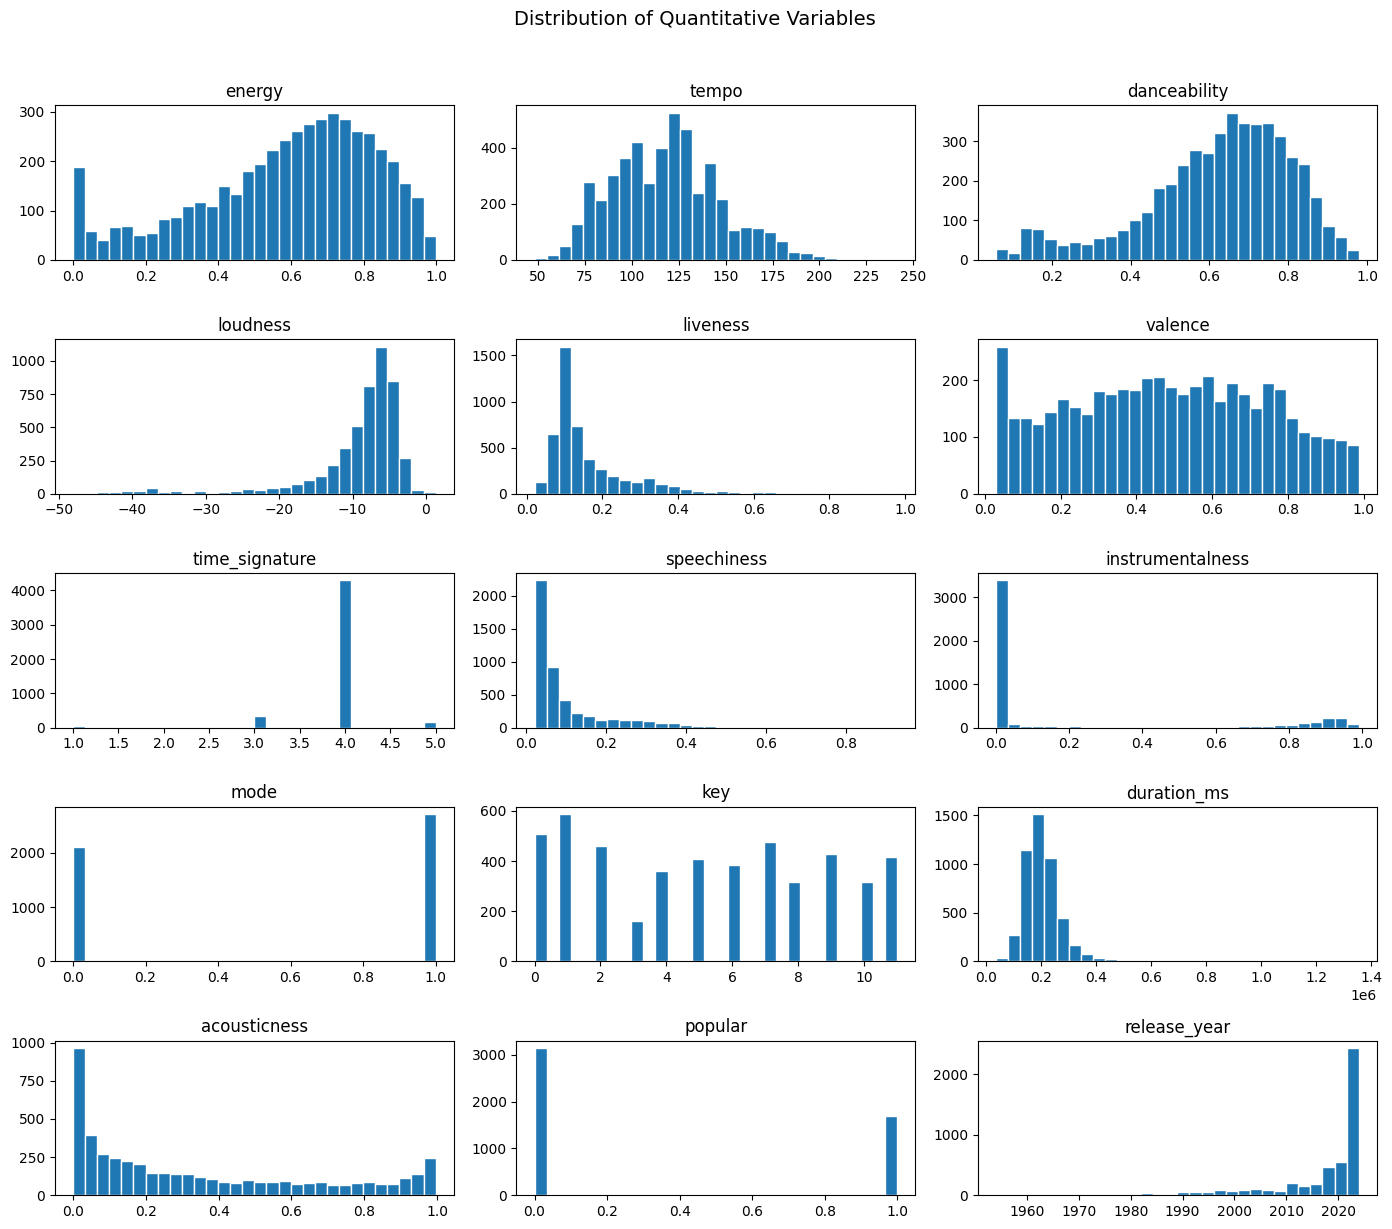

In [45]:
#visualization of quantitative variables
quant_vars = [
    'energy', 'tempo', 'danceability', 'loudness',
    'liveness', 'valence', 'time_signature',
    'speechiness', 'instrumentalness',
    'mode', 'key', 'duration_ms', 'acousticness', 'popular', 'release_year'
]

fig, axes = plt.subplots(5, 3, figsize=(14, 12))
axes = axes.flatten()

for i, var in enumerate(quant_vars):
    axes[i].hist(spotify_full[var], bins=30, edgecolor='white')
    axes[i].set_title(var)
    axes[i].set_xlabel('')

plt.suptitle('Distribution of Quantitative Variables', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('histogram_panel.png', dpi=150, bbox_inches='tight')
plt.show()

In [43]:
#check balance of target variable
spotify_full["popular"].value_counts(normalize = True)

popular
0    0.651066
1    0.348934
Name: proportion, dtype: float64

**Quick insights:**
- Target variable (whether a song is popular or not) is imbalanced
- Most distributions are skewed except for duration, valence, and tempo
- Most songs were released recently

In [44]:
#categorical variable summary
spotify_full.describe(include = ['str'])

,playlist_genre,playlist_subgenre
count,4829,4829
unique,35,84
top,electronic,modern
freq,589,694


Way too granular. I need to collapse these categorical variables a bit.

In [46]:
print(spotify_full['playlist_genre'].value_counts())
with pd.option_context('display.max_rows', 100):
    print(spotify_full['playlist_subgenre'].value_counts())

playlist_genre
electronic    589
pop           515
latin         425
hip-hop       395
ambient       359
rock          345
lofi          298
world         228
arabic        208
brazilian     148
jazz          146
gaming        133
classical     121
blues          88
afrobeats      82
wellness       80
punk           74
turkish        71
folk           68
indian         57
r&b            50
metal          49
soul           44
gospel         39
korean         34
funk           28
cantopop       27
reggae         24
j-pop          23
indie          17
k-pop          16
mandopop       14
soca           14
country        11
disco           9
Name: count, dtype: int64
playlist_subgenre
modern            694
chill             419
classic           293
meditative        231
french            161
reggaeton         158
throwback         150
scandi            134
hip-hop           125
jewish            101
soft               98
yoga               80
nordic             78
forró              74
pop

In [47]:
#collapse playlist genres and subgenres
genre_map = {
    # Electronic/Dance
    'electronic': 'electronic', 'ambient': 'electronic', 'lofi': 'electronic',
    'gaming': 'electronic', 'disco': 'electronic',
    
    # Pop/Mainstream
    'pop': 'pop', 'indie': 'pop', 'k-pop': 'pop', 'j-pop': 'pop',
    'cantopop': 'pop', 'mandopop': 'pop',
    
    # Hip-Hop/R&B/Soul
    'hip-hop': 'hip-hop_rnb', 'r&b': 'hip-hop_rnb', 'soul': 'hip-hop_rnb',
    'funk': 'hip-hop_rnb',
    
    # Latin/World
    'latin': 'latin_world', 'world': 'latin_world', 'arabic': 'latin_world',
    'brazilian': 'latin_world', 'afrobeats': 'latin_world', 'turkish': 'latin_world',
    'indian': 'latin_world', 'korean': 'latin_world', 'soca': 'latin_world',
    'reggae': 'latin_world',
    
    # Rock/Metal/Punk
    'rock': 'rock_metal', 'metal': 'rock_metal', 'punk': 'rock_metal',
    
    # Jazz/Blues/Gospel
    'jazz': 'jazz_blues', 'blues': 'jazz_blues', 'gospel': 'jazz_blues',
    
    # Classical/Folk/Acoustic
    'classical': 'classical_folk', 'folk': 'classical_folk',
    
    # Wellness/Lifestyle
    'wellness': 'wellness', 'country': 'wellness'
}

spotify_full['playlist_genre'] = spotify_full['playlist_genre'].map(genre_map)

subgenre_map = {
    # Chill/Relaxed
    'chill': 'chill', 'lofi': 'chill', 'meditative': 'chill',
    'yoga': 'chill', 'soft': 'chill', 'bedroom': 'chill', 'smooth': 'chill',
    
    # Modern/Mainstream
    'modern': 'modern', 'mainstream': 'modern', 'pop': 'modern',
    'feel-good': 'modern', 'essential': 'modern',
    
    # Classic/Throwback
    'classic': 'classic', 'throwback': 'classic', '80s': 'classic',
    '90s': 'classic', 'retro': 'classic',
    
    # Hip-Hop/Urban
    'hip-hop': 'urban', 'trap': 'urban', 'gangster': 'urban',
    'drill': 'urban', 'grime': 'urban',
    
    # Electronic/Dance
    'deep house': 'electronic', 'techno': 'electronic', 'hardstyle': 'electronic',
    'future': 'electronic', 'vaporwave': 'electronic', 'future bass': 'electronic',
    'afro house': 'electronic',
    
    # Latin/Tropical
    'reggaeton': 'latin', 'tropical': 'latin', 'afro-latin': 'latin',
    'cumbia': 'latin', 'samba': 'latin', 'forró': 'latin',
    'carnival': 'latin',
    
    # World/Global
    'french': 'world', 'scandi': 'world', 'nordic': 'world',
    'african': 'world', 'global': 'world', 'chinese': 'world',
    'japanese': 'world', 'nigerian': 'world', 'desi': 'world',
    'bhangra': 'world', 'bollywood': 'world', 'amapiano': 'world',
    'gqom': 'world', 'throat singing': 'world', 'australian': 'world',
    'celtic': 'world', 'irish': 'world', 'indigenous': 'world',
    'klezmer': 'world', 'jewish': 'world', 'tango': 'world',
    'cajun': 'world', 'southern': 'world', 'american': 'world',
    
    # Classical/Acoustic
    'classical': 'classical', 'neo-classical': 'classical', 'choral': 'classical',
    'cinematic': 'classical', 'academic': 'classical', 'soundtracks': 'classical',
    'noir': 'classical', 'drama': 'classical',
    
    # Alternative/Indie
    'alternative': 'alternative', 'indie': 'alternative', 'pop punk': 'alternative',
    'death': 'alternative', 'heavy': 'alternative', 'experimental': 'alternative',
    'post-rock': 'alternative', 'avant-garde': 'alternative',
    
    # Other
    'funk': 'other', 'melodic': 'other', 'workout': 'other',
    'anime': 'other', 'italo': 'other', 'delta': 'other',
    'fusion': 'other', 'latin': 'other', 'spanish': 'other',
    'afrobeats': 'other'
}

spotify_full['playlist_subgenre'] = spotify_full['playlist_subgenre'].map(subgenre_map)

# verify no NaNs from unmapped values
print(spotify_full['playlist_genre'].value_counts())
print(spotify_full['playlist_subgenre'].value_counts())
print(spotify_full[['playlist_genre', 'playlist_subgenre']].isna().sum())

playlist_genre
electronic        1388
latin_world       1291
pop                612
hip-hop_rnb        517
rock_metal         468
jazz_blues         273
classical_folk     189
wellness            91
Name: count, dtype: int64
playlist_subgenre
modern         913
world          896
chill          893
classic        557
latin          390
urban          294
electronic     248
alternative    221
classical      212
other          205
Name: count, dtype: int64
playlist_genre       0
playlist_subgenre    0
dtype: int64


In [48]:
#categorical variable summary after collapsing
spotify_full.describe(include = ['str'])

,playlist_genre,playlist_subgenre
count,4829,4829
unique,8,10
top,electronic,modern
freq,1388,913


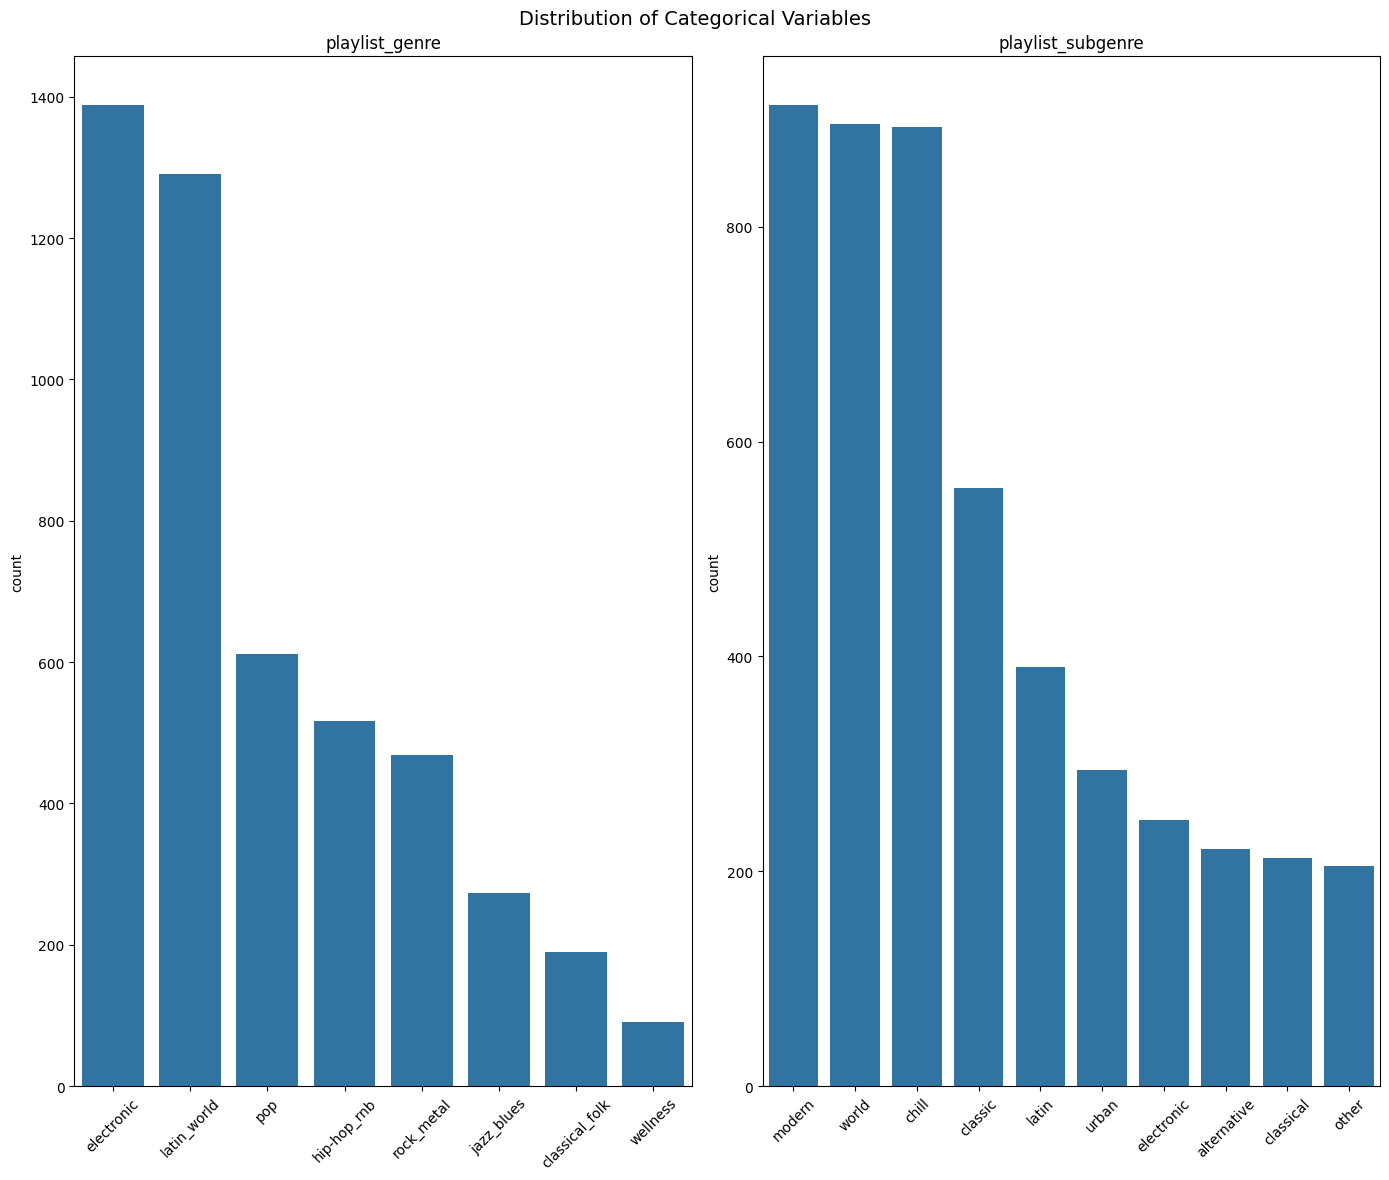

In [49]:
cat_vars = [
    'playlist_genre', 'playlist_subgenre'
]

fig, axes = plt.subplots(1, 2, figsize=(14, 12))
axes = axes.flatten()

for i, var in enumerate(cat_vars):
    order = spotify_full[var].value_counts().index  # sort bars by frequency
    sns.countplot(data=spotify_full, x=var, ax=axes[i], order=order)
    axes[i].set_title(var)
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=45)

plt.suptitle('Distribution of Categorical Variables', fontsize=14)
plt.tight_layout()
plt.savefig('categorical_panel.png', dpi=150, bbox_inches='tight')
plt.show()

In [22]:
#sweetviz to show visual of associations between variables
project_report_spotify = sv.analyze(spotify_full)
project_report_spotify.show_html('project_report_spotify.html')

Done! Use 'show' commands to display/save.   |██████████| [100%]   00:00 -> (00:00 left)

Report project_report_spotify.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


## Data preprocessing for modeling

In [50]:
quant_vars = [
    'energy', 'tempo', 'danceability', 'loudness',
    'liveness', 'valence', 'time_signature',
    'speechiness', 'instrumentalness',
    'mode', 'key', 'duration_ms', 'acousticness', 'release_year'
]

y = spotify_full['popular']

# one-hot encode categorical variables
X = pd.concat([
    spotify_full[quant_vars],
    pd.get_dummies(spotify_full[cat_vars], drop_first=True).astype(int)
], axis=1)

# train + test + validation split
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, stratify=y, test_size=0.2, random_state=321)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, stratify=y_train_full, test_size=0.2, random_state=321)

# scaled variables for logistic regression and multilayer perceptron
scaler = MinMaxScaler()
X_train_scaled = X_train.copy()
X_val_scaled   = X_val.copy()
X_test_scaled  = X_test.copy()
X_train_scaled[quant_vars] = scaler.fit_transform(X_train[quant_vars])
X_val_scaled[quant_vars]   = scaler.transform(X_val[quant_vars])
X_test_scaled[quant_vars]  = scaler.transform(X_test[quant_vars])

# Baseline modeling

In [51]:
#model definitions

#Random Forest
rf_model = RandomForestClassifier(random_state=321, class_weight='balanced', n_jobs=-1)

#Extra Trees
et_model = ExtraTreesClassifier(class_weight='balanced', random_state=321, n_jobs=-1)

#XGBoost
xgb_model = XGBClassifier(scale_pos_weight=(y_train==0).sum()/(y_train==1).sum(),
                           random_state=321, eval_metric='auc')

#LightGBM
lgbm_model = LGBMClassifier(class_weight='balanced', random_state=321, n_jobs=-1, verbose=-1)

#Logistic Regression
lr_model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=321)

#Naive Bayes
nb_model = GaussianNB()

#MLP
tf.random.set_seed(321)

input_dim = X_train_scaled.shape[1]
inputs = keras.Input(shape=(input_dim,))
x = layers.Dense(64, activation='relu')(inputs)
x = layers.Dense(32, activation='relu')(x)
outputs = layers.Dense(1, activation='sigmoid')(x)
model = keras.Model(inputs=inputs, outputs=outputs, name="spotify_popularity_mlp")

In [52]:
#define cross validation method
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=321)

In [32]:
#evaluate models - Random Forest
cv_scores_rf = cross_val_score(rf_model, X_train, y_train, cv=cv, scoring="roc_auc", n_jobs=-1)
print(cv_scores_rf)
print(cv_scores_rf.mean())
print(cv_scores_rf.std())

rf_model.fit(X_train, y_train)

y_proba = rf_model.predict_proba(X_val)[:,1]
print("Random Forest Baseline ROC AUC:", roc_auc_score(y_val, y_proba))
print(classification_report(y_val, rf_model.predict(X_val)))

[0.90195049 0.89135553 0.90506956 0.89864912 0.89097913]
0.8976007652144784
0.005632956346634261
Random Forest Baseline ROC AUC: 0.9018113540976364
              precision    recall  f1-score   support

           0       0.84      0.94      0.88       503
           1       0.85      0.66      0.74       270

    accuracy                           0.84       773
   macro avg       0.84      0.80      0.81       773
weighted avg       0.84      0.84      0.83       773



In [33]:
#evaluate models - Extra Trees
cv_scores_et = cross_val_score(et_model, X_train, y_train, cv=cv, scoring="roc_auc", n_jobs=-1)
print(cv_scores_et)
print(cv_scores_et.mean())
print(cv_scores_et.std())

et_model.fit(X_train, y_train)

y_proba = et_model.predict_proba(X_val)[:,1]
print("Extra Trees Baseline ROC AUC:", roc_auc_score(y_val, y_proba))
print(classification_report(y_val, et_model.predict(X_val)))

[0.89953835 0.89557966 0.90564538 0.90075088 0.88385618]
0.8970740903536042
0.007348534429084348
Extra Trees Baseline ROC AUC: 0.8978278477284442
              precision    recall  f1-score   support

           0       0.86      0.93      0.89       503
           1       0.85      0.72      0.78       270

    accuracy                           0.86       773
   macro avg       0.85      0.83      0.84       773
weighted avg       0.86      0.86      0.85       773



In [34]:
#evaluate models - XGBoost
cv_scores_xgb = cross_val_score(xgb_model, X_train, y_train, cv=cv, scoring="roc_auc", n_jobs=-1)
print(cv_scores_xgb)
print(cv_scores_xgb.mean())
print(cv_scores_xgb.std())

xgb_model.fit(X_train, y_train)

y_proba = xgb_model.predict_proba(X_val)[:,1]
print("XGBoost Baseline ROC AUC:", roc_auc_score(y_val, y_proba))
print(classification_report(y_val, xgb_model.predict(X_val)))

[0.88376132 0.8954354  0.88588884 0.89048392 0.88218629]
0.8875511557652989
0.004830533441738307
XGBoost Baseline ROC AUC: 0.9075546719681908
              precision    recall  f1-score   support

           0       0.88      0.88      0.88       503
           1       0.78      0.78      0.78       270

    accuracy                           0.85       773
   macro avg       0.83      0.83      0.83       773
weighted avg       0.85      0.85      0.85       773



In [35]:
#evaluate models - LGBM
cv_scores_lgbm = cross_val_score(lgbm_model, X_train, y_train, cv=cv, scoring="roc_auc", n_jobs=-1)
print(cv_scores_lgbm)
print(cv_scores_lgbm.mean())
print(cv_scores_lgbm.std())

lgbm_model.fit(X_train, y_train)

y_proba = lgbm_model.predict_proba(X_val)[:,1]
print("LightGBM Baseline ROC AUC:", roc_auc_score(y_val, y_proba))
print(classification_report(y_val, lgbm_model.predict(X_val)))

[0.8965953  0.89795141 0.89376612 0.90273747 0.89098489]
0.8964070394219723
0.003971624804303635
LightGBM Baseline ROC AUC: 0.9100139901332744
              precision    recall  f1-score   support

           0       0.90      0.87      0.89       503
           1       0.77      0.81      0.79       270

    accuracy                           0.85       773
   macro avg       0.84      0.84      0.84       773
weighted avg       0.85      0.85      0.85       773



In [36]:
##evaluate models - Logistic Regression
cv_scores_lr = cross_val_score(lr_model, X_train_scaled, y_train, cv=cv, scoring="roc_auc", n_jobs=-1)
print(cv_scores_lr)
print(cv_scores_lr.mean())
print(cv_scores_lr.std())

lr_model.fit(X_train_scaled, y_train)

y_proba = lr_model.predict_proba(X_val_scaled)[:,1]
print("Logistic Regression Baseline ROC AUC:", roc_auc_score(y_val, y_proba))
print(classification_report(y_val, lr_model.predict(X_val_scaled)))

[0.83893473 0.83146171 0.86511309 0.85336627 0.82476506]
0.8427281742566441
0.014685028769424893
Logistic Regression Baseline ROC AUC: 0.8307414770635447
              precision    recall  f1-score   support

           0       0.83      0.73      0.78       503
           1       0.59      0.73      0.65       270

    accuracy                           0.73       773
   macro avg       0.71      0.73      0.71       773
weighted avg       0.75      0.73      0.73       773



In [37]:
#evaluate models - Naive Bayes
cv_scores_nb = cross_val_score(nb_model, X_train, y_train, cv=cv, scoring="roc_auc", n_jobs=-1)
print(cv_scores_nb)
print(cv_scores_nb.mean())
print(cv_scores_nb.std())

nb_model.fit(X_train, y_train)

y_proba = nb_model.predict_proba(X_val)[:,1]
print("Naive Bayes Baseline ROC AUC:", roc_auc_score(y_val, y_proba))
print(classification_report(y_val, nb_model.predict(X_val)))

[0.73947141 0.70491084 0.73793648 0.72705339 0.74193846]
0.7302621141529377
0.013660356399927695
Naive Bayes Baseline ROC AUC: 0.732508651792946
              precision    recall  f1-score   support

           0       0.74      0.83      0.78       503
           1       0.58      0.45      0.51       270

    accuracy                           0.70       773
   macro avg       0.66      0.64      0.64       773
weighted avg       0.68      0.70      0.68       773



In [40]:
#evaluate models - MLP
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=[keras.metrics.AUC(name='auc')]
)

class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(enumerate(class_weights))

history = model.fit(
    X_train_scaled, y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_val_scaled, y_val),
    class_weight=class_weight_dict,
    verbose=1
)

y_proba = model.predict(X_val_scaled).flatten()
y_pred = (y_proba > 0.5).astype(int)
print("Keras MLP Baseline ROC AUC:", roc_auc_score(y_val, y_proba))
print(classification_report(y_val, y_pred, zero_division=0))

Epoch 1/20
97/97 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - auc: 0.7738 - loss: 0.5811 - val_auc: 0.8034 - val_loss: 0.5199
Epoch 2/20
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 535us/step - auc: 0.8329 - loss: 0.5022 - val_auc: 0.8285 - val_loss: 0.4908
Epoch 3/20
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 531us/step - auc: 0.8531 - loss: 0.4755 - val_auc: 0.8462 - val_loss: 0.4703
Epoch 4/20
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 552us/step - auc: 0.8669 - loss: 0.4555 - val_auc: 0.8569 - val_loss: 0.4509
Epoch 5/20
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 534us/step - auc: 0.8771 - loss: 0.4386 - val_auc: 0.8649 - val_loss: 0.4354
Epoch 6/20
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 530us/step - auc: 0.8850 - loss: 0.4249 - val_auc: 0.8715 - val_loss: 0.4219
Epoch 7/20
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 559us/step - auc: 0.8910 - loss: 0.4136 - val_auc: 0.8756 - val_loss: 0.4139
Epoch 8/20
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 565us/step - auc: 0.8959 - loss: 0.4045 - val_auc: 0.8781 - val_loss: 0.4086
Epoch 9/20
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 535us/step - auc:

# Model tuning with full, untouched feature set

Best baseline bagging model = Random Forest

Best baseline boosting model = Light GBM

In [39]:
#Random Forest model tuning
def objective_rf(trial):
    clf = RandomForestClassifier(
        n_estimators=trial.suggest_int('n_estimators', 100, 1000),
        max_depth=trial.suggest_int('max_depth', 3, 20),
        min_samples_split=trial.suggest_int('min_samples_split', 2, 20),
        min_samples_leaf=trial.suggest_int('min_samples_leaf', 1, 10),
        max_features=trial.suggest_categorical('max_features', ['sqrt', 'log2', 0.5]),
        class_weight='balanced',
        random_state=321,
        n_jobs=-1
    )
    return cross_val_score(clf, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1).mean()

study_rf = optuna.create_study(direction='maximize')
study_rf.optimize(objective_rf, n_trials=50)

#define best model
best_rf = RandomForestClassifier(
    class_weight='balanced',
    random_state=321,
    n_jobs=-1,
    **study_rf.best_params
)

#make predictions using best model and display results
best_rf.fit(X_train, y_train)
y_proba_rf = best_rf.predict_proba(X_val)[:, 1]
y_pred_rf = best_rf.predict(X_val)

print("=== Random Forest Results ===")
print(f"ROC AUC Score: {roc_auc_score(y_val, y_proba_rf):.4f}")
print(classification_report(y_val, y_pred_rf))

[I 2026-05-20 14:57:29,813] A new study created in memory with name: no-name-e4bf3156-907e-4821-8f66-b7dca3c3f8fa
[I 2026-05-20 14:57:33,166] Trial 0 finished with value: 0.8946434602655001 and parameters: {'n_estimators': 467, 'max_depth': 12, 'min_samples_split': 4, 'min_samples_leaf': 5, 'max_features': 0.5}. Best is trial 0 with value: 0.8946434602655001.
[I 2026-05-20 14:57:35,288] Trial 1 finished with value: 0.8889311396661089 and parameters: {'n_estimators': 579, 'max_depth': 11, 'min_samples_split': 3, 'min_samples_leaf': 8, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.8946434602655001.
[I 2026-05-20 14:57:37,733] Trial 2 finished with value: 0.8828605534202362 and parameters: {'n_estimators': 861, 'max_depth': 7, 'min_samples_split': 9, 'min_samples_leaf': 5, 'max_features': 0.5}. Best is trial 0 with value: 0.8946434602655001.
[I 2026-05-20 14:57:40,012] Trial 3 finished with value: 0.890994445867707 and parameters: {'n_estimators': 675, 'max_depth': 13, 'min_sampl

=== Random Forest Results ===
ROC AUC Score: 0.9059
              precision    recall  f1-score   support

           0       0.87      0.93      0.90       503
           1       0.84      0.74      0.79       270

    accuracy                           0.86       773
   macro avg       0.86      0.83      0.84       773
weighted avg       0.86      0.86      0.86       773



In [40]:
# LightGBM model tuning
def objective_lgbm(trial):
    clf = LGBMClassifier(
        n_estimators=trial.suggest_int('n_estimators', 100, 1000),
        max_depth=trial.suggest_int('max_depth', 3, 20),
        learning_rate=trial.suggest_float('learning_rate', 1e-3, 0.3, log=True),
        num_leaves=trial.suggest_int('num_leaves', 20, 300),
        min_child_samples=trial.suggest_int('min_child_samples', 5, 100),
        subsample=trial.suggest_float('subsample', 0.5, 1.0),
        colsample_bytree=trial.suggest_float('colsample_bytree', 0.5, 1.0),
        reg_alpha=trial.suggest_float('reg_alpha', 1e-8, 10, log=True),
        reg_lambda=trial.suggest_float('reg_lambda', 1e-8, 10, log=True),
        class_weight='balanced',
        random_state=321,
        n_jobs=-1,
        verbose=-1
    )
    return cross_val_score(clf, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1).mean()

study_lgbm = optuna.create_study(direction='maximize')
study_lgbm.optimize(objective_lgbm, n_trials=50)

# Define best model
best_lgbm = LGBMClassifier(
    class_weight='balanced',
    random_state=321,
    n_jobs=-1,
    verbose=-1,
    **study_lgbm.best_params
)

# Make predictions using best model and display results
best_lgbm.fit(X_train, y_train)
y_proba_lgbm = best_lgbm.predict_proba(X_val)[:, 1]
y_pred_lgbm = best_lgbm.predict(X_val)

print("=== LightGBM Results ===")
print(f"ROC AUC Score: {roc_auc_score(y_val, y_proba_lgbm):.4f}")
print(classification_report(y_val, y_pred_lgbm))

[I 2026-05-20 14:58:52,407] A new study created in memory with name: no-name-51198985-e6e5-4245-a953-d96d83a79281
[I 2026-05-20 14:58:55,149] Trial 0 finished with value: 0.8964783770463175 and parameters: {'n_estimators': 138, 'max_depth': 18, 'learning_rate': 0.030303107141389698, 'num_leaves': 60, 'min_child_samples': 41, 'subsample': 0.8582796934881738, 'colsample_bytree': 0.5618868687502823, 'reg_alpha': 9.279440250485766e-06, 'reg_lambda': 0.10257941141214265}. Best is trial 0 with value: 0.8964783770463175.
[I 2026-05-20 14:59:24,699] Trial 1 finished with value: 0.89550691718939 and parameters: {'n_estimators': 567, 'max_depth': 20, 'learning_rate': 0.00457907103312578, 'num_leaves': 127, 'min_child_samples': 9, 'subsample': 0.8353220554801145, 'colsample_bytree': 0.951171633547332, 'reg_alpha': 0.0007665261022454303, 'reg_lambda': 2.993523728070662e-06}. Best is trial 0 with value: 0.8964783770463175.
[I 2026-05-20 14:59:27,680] Trial 2 finished with value: 0.8492507163073032 

=== LightGBM Results ===
ROC AUC Score: 0.9158
              precision    recall  f1-score   support

           0       0.89      0.91      0.90       503
           1       0.82      0.80      0.81       270

    accuracy                           0.87       773
   macro avg       0.86      0.85      0.86       773
weighted avg       0.87      0.87      0.87       773



In [53]:
# Logistic Regression model tuning
def objective_lr(trial):
    clf = LogisticRegression(
        C=trial.suggest_float('C', 1e-4, 10, log=True),
        l1_ratio=trial.suggest_float('l1_ratio', 0.0, 1.0),
        solver='saga',
        max_iter=1000,
        class_weight='balanced',
        random_state=321
    )
    return cross_val_score(clf, X_train_scaled, y_train, cv=cv, scoring='roc_auc', n_jobs=-1).mean()

study_lr = optuna.create_study(direction='maximize')
study_lr.optimize(objective_lr, n_trials=50)

# Define best model
best_lr = LogisticRegression(
    solver='saga',
    max_iter=1000,
    class_weight='balanced',
    random_state=321,
    **study_lr.best_params  # contains C and l1_ratio
)

# Make predictions using best model and display results
best_lr.fit(X_train_scaled, y_train)
y_proba_lr = best_lr.predict_proba(X_val_scaled)[:, 1]
y_pred_lr = best_lr.predict(X_val_scaled)

print("=== Logistic Regression Results ===")
print(f"ROC AUC Score: {roc_auc_score(y_val, y_proba_lr):.4f}")
print(classification_report(y_val, y_pred_lr))

[I 2026-05-24 10:12:43,208] A new study created in memory with name: no-name-b3f3ec0e-cf3e-4eda-9582-f3eec90178d2
[I 2026-05-24 10:12:44,610] Trial 0 finished with value: 0.8424236914833164 and parameters: {'C': 0.6696661767594548, 'l1_ratio': 0.3600412061217856}. Best is trial 0 with value: 0.8424236914833164.
[I 2026-05-24 10:12:45,360] Trial 1 finished with value: 0.8462691722437349 and parameters: {'C': 4.939517167438158, 'l1_ratio': 0.13009758149303718}. Best is trial 1 with value: 0.8462691722437349.
[I 2026-05-24 10:12:45,425] Trial 2 finished with value: 0.8371566630601818 and parameters: {'C': 0.21367653707825204, 'l1_ratio': 0.5404002938164112}. Best is trial 1 with value: 0.8462691722437349.
[I 2026-05-24 10:12:46,001] Trial 3 finished with value: 0.5 and parameters: {'C': 0.0023848181530922146, 'l1_ratio': 0.9401294063931586}. Best is trial 1 with value: 0.8462691722437349.
[I 2026-05-24 10:12:46,041] Trial 4 finished with value: 0.8286562727714714 and parameters: {'C': 0.0

=== Logistic Regression Results ===
ROC AUC Score: 0.8334
              precision    recall  f1-score   support

           0       0.84      0.74      0.79       503
           1       0.60      0.74      0.67       270

    accuracy                           0.74       773
   macro avg       0.72      0.74      0.73       773
weighted avg       0.76      0.74      0.74       773



In [35]:
# Naive Bayes (no tuning because there are no useful/meaningful hyperparameters)
# tuning of this model will come in the feature engineering stage
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)
y_proba_nb = nb_model.predict_proba(X_val)[:, 1]
y_pred_nb = nb_model.predict(X_val)

print("=== Naive Bayes Results ===")
print(f"ROC AUC Score: {roc_auc_score(y_val, y_proba_nb):.4f}")
print(classification_report(y_val, y_pred_nb))

=== Naive Bayes Results ===
ROC AUC Score: 0.7325
              precision    recall  f1-score   support

           0       0.74      0.83      0.78       503
           1       0.58      0.45      0.51       270

    accuracy                           0.70       773
   macro avg       0.66      0.64      0.64       773
weighted avg       0.68      0.70      0.68       773



In [54]:
# MLP model tuning
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(enumerate(class_weights))

def objective_mlp(trial):
    tf.random.set_seed(321)
    input_dim = X_train_scaled.shape[1]
    num_layers = trial.suggest_int('num_layers', 1, 4)

    inputs = keras.Input(shape=(input_dim,))
    x = inputs
    for i in range(num_layers):
        units = trial.suggest_int(f'num_units_layer_{i+1}', 16, 256)
        x = layers.Dense(units, activation='relu')(x)
        dropout_rate = trial.suggest_float(f'dropout_layer_{i+1}', 0.0, 0.5)
        x = layers.Dropout(dropout_rate)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)
    clf = keras.Model(inputs=inputs, outputs=outputs)

    clf.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=trial.suggest_float('learning_rate', 1e-4, 1e-2, log=True)
        ),
        loss='binary_crossentropy',
        metrics=[keras.metrics.AUC(name='auc')]
    )
    clf.fit(
        X_train_scaled, y_train,
        epochs=20,
        batch_size=trial.suggest_categorical('batch_size', [32, 64, 128]),
        validation_data=(X_val_scaled, y_val),
        class_weight=class_weight_dict,
        verbose=0,
        callbacks=[keras.callbacks.EarlyStopping(
            monitor='val_auc', patience=5, restore_best_weights=True, mode='max')]
    )
    y_proba = clf.predict(X_val_scaled).flatten()
    return roc_auc_score(y_val, y_proba)

study_mlp = optuna.create_study(direction='maximize')
study_mlp.optimize(objective_mlp, n_trials=50)

# Define best model
tf.random.set_seed(321)
best_params_mlp = study_mlp.best_params
num_layers = best_params_mlp['num_layers']
learning_rate = best_params_mlp['learning_rate']
batch_size = best_params_mlp['batch_size']

input_dim = X_train_scaled.shape[1]
inputs = keras.Input(shape=(input_dim,))
x = inputs
for i in range(num_layers):
    units = best_params_mlp[f'num_units_layer_{i+1}']
    x = layers.Dense(units, activation='relu')(x)
    dropout_rate = best_params_mlp[f'dropout_layer_{i+1}']
    x = layers.Dropout(dropout_rate)(x)
outputs = layers.Dense(1, activation='sigmoid')(x)
best_mlp = keras.Model(inputs=inputs, outputs=outputs)

best_mlp.compile(
    optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
    loss='binary_crossentropy',
    metrics=[keras.metrics.AUC(name='auc')]
)

# Make predictions using best model and display results
best_mlp.fit(
    X_train_scaled, y_train,
    epochs=20,
    batch_size=batch_size,
    validation_data=(X_val_scaled, y_val),
    class_weight=class_weight_dict,
    verbose=1,
    callbacks=[keras.callbacks.EarlyStopping(
        monitor='val_auc', patience=5, restore_best_weights=True, mode='max')]
)
y_proba_mlp = best_mlp.predict(X_val_scaled).flatten()
y_pred_mlp = (y_proba_mlp > 0.5).astype(int)

print("=== MLP Results ===")
print(f"ROC AUC Score: {roc_auc_score(y_val, y_proba_mlp):.4f}")
print(classification_report(y_val, y_pred_mlp, zero_division=0))

[I 2026-05-24 10:12:55,468] A new study created in memory with name: no-name-70fbcdf5-8a95-4272-85e8-9dc09123ed40


25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


[I 2026-05-24 10:12:58,600] Trial 0 finished with value: 0.8802812753110963 and parameters: {'num_layers': 3, 'num_units_layer_1': 83, 'dropout_layer_1': 0.3663390328340837, 'num_units_layer_2': 173, 'dropout_layer_2': 0.1618859371800549, 'num_units_layer_3': 213, 'dropout_layer_3': 0.09434574544476898, 'learning_rate': 0.0053094611220013245, 'batch_size': 32}. Best is trial 0 with value: 0.8802812753110963.


25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


[I 2026-05-24 10:13:00,785] Trial 1 finished with value: 0.8875414181577204 and parameters: {'num_layers': 3, 'num_units_layer_1': 224, 'dropout_layer_1': 0.0634832398491173, 'num_units_layer_2': 88, 'dropout_layer_2': 0.12189071113430261, 'num_units_layer_3': 197, 'dropout_layer_3': 0.24422405740917547, 'learning_rate': 0.00045234065822853735, 'batch_size': 64}. Best is trial 1 with value: 0.8875414181577204.


...

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


[I 2026-05-24 10:14:50,370] Trial 48 finished with value: 0.881076503939327 and parameters: {'num_layers': 4, 'num_units_layer_1': 157, 'dropout_layer_1': 0.030455107775754477, 'num_units_layer_2': 147, 'dropout_layer_2': 0.18422442273296255, 'num_units_layer_3': 220, 'dropout_layer_3': 0.12859680460315415, 'num_units_layer_4': 156, 'dropout_layer_4': 0.21040859162333, 'learning_rate': 0.0009303925407844304, 'batch_size': 64}. Best is trial 12 with value: 0.8886090862234002.


25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


[I 2026-05-24 10:14:52,803] Trial 49 finished with value: 0.878425741845225 and parameters: {'num_layers': 4, 'num_units_layer_1': 57, 'dropout_layer_1': 0.2326921073499078, 'num_units_layer_2': 25, 'dropout_layer_2': 0.14603057566331296, 'num_units_layer_3': 204, 'dropout_layer_3': 0.2957598513660264, 'num_units_layer_4': 220, 'dropout_layer_4': 0.13938151048980768, 'learning_rate': 0.0006007594018814287, 'batch_size': 64}. Best is trial 12 with value: 0.8886090862234002.


Epoch 1/20
97/97 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - auc: 0.7738 - loss: 0.5921 - val_auc: 0.8020 - val_loss: 0.5424
Epoch 2/20
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 778us/step - auc: 0.8299 - loss: 0.5073 - val_auc: 0.8255 - val_loss: 0.5040
Epoch 3/20
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 780us/step - auc: 0.8511 - loss: 0.4774 - val_auc: 0.8427 - val_loss: 0.4820
Epoch 4/20
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 766us/step - auc: 0.8628 - loss: 0.4599 - val_auc: 0.8527 - val_loss: 0.4648
Epoch 5/20
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 808us/step - auc: 0.8717 - loss: 0.4453 - val_auc: 0.8613 - val_loss: 0.4482
Epoch 6/20
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 880us/step - auc: 0.8821 - loss: 0.4300 - val_auc: 0.8682 - val_loss: 0.4344
Epoch 7/20
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 830us/step - auc: 0.8842 - loss: 0.4248 - val_auc: 0.8742 - val_loss: 0.4245
Epoch 8/20
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 781us/step - auc: 0.8928 - loss: 0.4100 - val_auc: 0.8780 - val_loss: 0.4148
Epoch 9/20
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 759us/step - auc:

# Feature engineering

In [58]:
#interactions
X['energy_x_acousticness'] = X['energy'] * X['acousticness']
X['energy_x_loudness'] = X['energy'] * X['loudness']
X['loudness_x_instrumentalness'] = X['loudness'] * X['instrumentalness']

genre_dummies = pd.get_dummies(spotify_full['playlist_genre'], prefix='genre').astype(int)
subgenre_dummies = pd.get_dummies(spotify_full['playlist_subgenre'], prefix='subgenre').astype(int)

for col in genre_dummies.columns:
    X[f'{col}_x_release_year'] = genre_dummies[col] * spotify_full['release_year']
    X[f'{col}_x_loudness'] = genre_dummies[col] * spotify_full['loudness']
    X[f'{col}_x_danceability'] = genre_dummies[col] * spotify_full['danceability']
    X[f'{col}_x_energy'] = genre_dummies[col] * spotify_full['energy']

for col in subgenre_dummies.columns:
    X[f'{col}_x_release_year'] = subgenre_dummies[col] * spotify_full['release_year']

#log transformations
X['log_loudness'] = np.log1p(X['loudness'] - X['loudness'].min() + 1)
X['log_liveness'] = np.log1p(X['liveness'])
X['log_speechiness'] = np.log1p(X['speechiness'])
X['log_instrumentalness'] = np.log1p(X['instrumentalness'])
X['log_acousticness'] = np.log1p(X['acousticness'])

#polynomials
X['energy_sq'] = X['energy'] ** 2
X['danceability_sq'] = X['danceability'] ** 2

#variable transformations
X['dancefloor_score'] = (X['danceability'] + X['energy'] + X['valence']) / 3
X['chill_score'] = (X['acousticness'] + X['valence'] - X['energy']) / 3
X['mainstream_score'] = (X['danceability'] + (X['loudness'] / X['loudness'].min()) - X['instrumentalness']) / 3
X['vocal_score'] = (X['speechiness'] - X['instrumentalness'] + 1) / 2
X['complexity_score'] = (abs(X['time_signature'] - 4) + X['liveness'] + X['speechiness']) / 3

In [59]:
#define train, validation, test split
new_quant_vars = [
    # interactions
    'energy_x_acousticness', 'energy_x_loudness', 'loudness_x_instrumentalness',
    # genre/subgenre continuous interactions
    *[f'{col}_x_release_year' for col in genre_dummies.columns],
    *[f'{col}_x_loudness' for col in genre_dummies.columns],
    *[f'{col}_x_danceability' for col in genre_dummies.columns],
    *[f'{col}_x_energy' for col in genre_dummies.columns],
    *[f'{col}_x_release_year' for col in subgenre_dummies.columns],
    # log transforms
    'log_loudness', 'log_liveness', 'log_speechiness',
    'log_instrumentalness', 'log_acousticness',
    # polynomials
    'energy_sq', 'danceability_sq',
    # composites
    'dancefloor_score', 'chill_score',
    'mainstream_score', 'vocal_score', 'complexity_score'
]

quant_vars_all = quant_vars + new_quant_vars

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, stratify=y, test_size=0.2, random_state=321)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, stratify=y_train_full, test_size=0.2, random_state=321)

scaler = MinMaxScaler()
X_train_scaled = X_train.copy()
X_val_scaled   = X_val.copy()
X_test_scaled  = X_test.copy()
X_train_scaled[quant_vars_all] = scaler.fit_transform(X_train[quant_vars_all])
X_val_scaled[quant_vars_all]   = scaler.transform(X_val[quant_vars_all])
X_test_scaled[quant_vars_all]  = scaler.transform(X_test[quant_vars_all])

# Evaluating full feature engineered dataset on baseline models

In [ ]:
#evaluate models - Random Forest
cv_scores_rf = cross_val_score(rf_model, X_train, y_train, cv=cv, scoring="roc_auc", n_jobs=-1)
print(cv_scores_rf)
print(cv_scores_rf.mean())
print(cv_scores_rf.std())

rf_model.fit(X_train, y_train)

y_proba = rf_model.predict_proba(X_val)[:,1]
print("Random Forest Baseline ROC AUC (Full engineered feature set):", roc_auc_score(y_val, y_proba))
print(classification_report(y_val, rf_model.predict(X_val)))

[0.90200242 0.89109008 0.90901396 0.90598512
 0.89062788]
0.8997438923397558
0.007589178790999549
Random Forest Baseline ROC AUC (Full engineered feature set): 0.9011449819600913
              precision    recall  f1-score   support

           0       0.86      0.92      0.89       503
           1       0.83      0.72      0.77       270

    accuracy                           0.85       773
   macro avg       0.85      0.82      0.83       773
weighted avg       0.85      0.85      0.85       773



In [58]:
#evaluate models - LGBM
cv_scores_lgbm = cross_val_score(lgbm_model, X_train, y_train, cv=cv, scoring="roc_auc", n_jobs=-1)
print(cv_scores_lgbm)
print(cv_scores_lgbm.mean())
print(cv_scores_lgbm.std())

lgbm_model.fit(X_train, y_train)

y_proba = lgbm_model.predict_proba(X_val)[:,1]
print("LightGBM Baseline ROC AUC (Full engineered feature set):", roc_auc_score(y_val, y_proba))
print(classification_report(y_val, lgbm_model.predict(X_val)))

[0.9041318  0.89586243 0.91063778 0.90149369
 0.9001405 ]
0.9024532405585131
0.004889021030158514
LightGBM Baseline ROC AUC (Full engineered feature set): 0.906877254988587
              precision    recall  f1-score   support

           0       0.88      0.89      0.89       503
           1       0.79      0.79      0.79       270

    accuracy                           0.85       773
   macro avg       0.84      0.84      0.84       773
weighted avg       0.85      0.85      0.85       773



In [59]:
##evaluate models - Logistic Regression
cv_scores_lr = cross_val_score(lr_model, X_train_scaled, y_train, cv=cv, scoring="roc_auc", n_jobs=-1)
print(cv_scores_lr)
print(cv_scores_lr.mean())
print(cv_scores_lr.std())

lr_model.fit(X_train_scaled, y_train)

y_proba = lr_model.predict_proba(X_val_scaled)[:,1]
print("Logistic Regression Baseline ROC AUC (Full engineered feature set):", roc_auc_score(y_val, y_proba))
print(classification_report(y_val, lr_model.predict(X_val_scaled)))

[0.84066594 0.84205667 0.86603441 0.85967731
 0.83035056]
0.847756976982903
0.013129497817294798
Logistic Regression Baseline ROC AUC (Full engineered feature set): 0.8381488844709521
              precision    recall  f1-score   support

           0       0.85      0.75      0.79       503
           1       0.62      0.75      0.68       270

    accuracy                           0.75       773
   macro avg       0.73      0.75      0.74       773
weighted avg       0.77      0.75      0.75       773



In [60]:
#evaluate models - Naive Bayes
cv_scores_nb = cross_val_score(nb_model, X_train, y_train, cv=cv, scoring="roc_auc", n_jobs=-1)
print(cv_scores_nb)
print(cv_scores_nb.mean())
print(cv_scores_nb.std())

nb_model.fit(X_train, y_train)

y_proba = nb_model.predict_proba(X_val)[:,1]
print("Naive Bayes Baseline ROC AUC (Full engineered feature set):", roc_auc_score(y_val, y_proba))
print(classification_report(y_val, nb_model.predict(X_val)))

[0.79994806 0.79707427 0.81090497 0.79340566
 0.77871061]
0.7960087137833487
0.010436018294695645
Naive Bayes Baseline ROC AUC (Full engineered feature set): 0.7761910021353362
              precision    recall  f1-score   support

           0       0.85      0.61      0.71       503
           1       0.52      0.81      0.64       270

    accuracy                           0.68       773
   macro avg       0.69      0.71      0.67       773
weighted avg       0.74      0.68      0.68       773



In [61]:
#evaluate models - MLP
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=[keras.metrics.AUC(name='auc')]
)

class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(enumerate(class_weights))

history = model.fit(
    X_train_scaled, y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_val_scaled, y_val),
    class_weight=class_weight_dict,
    verbose=1
)

y_proba = model.predict(X_val_scaled).flatten()
y_pred = (y_proba > 0.5).astype(int)
print("Keras MLP Baseline ROC AUC (Full engineered feature set):", roc_auc_score(y_val, y_proba))
print(classification_report(y_val, y_pred, zero_division=0))

Epoch 1/20
97/97 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - auc: 0.7804 - loss: 0.5718 - val_auc: 0.8035 - val_loss: 0.5121
Epoch 2/20
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 573us/step - auc: 0.8380 - loss: 0.4967 - val_auc: 0.8302 - val_loss: 0.4818
Epoch 3/20
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 572us/step - auc: 0.8569 - loss: 0.4714 - val_auc: 0.8459 - val_loss: 0.4596
Epoch 4/20
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 564us/step - auc: 0.8695 - loss: 0.4523 - val_auc: 0.8556 - val_loss: 0.4418
Epoch 5/20
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 550us/step - auc: 0.8786 - loss: 0.4373 - val_auc: 0.8625 - val_loss: 0.4288
Epoch 6/20
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 569us/step - auc: 0.8851 - loss: 0.4254 - val_auc: 0.8690 - val_loss: 0.4179
Epoch 7/20
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 545us/step - auc: 0.8903 - loss: 0.4160 - val_auc: 0.8740 - val_loss: 0.4107
Epoch 8/20
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 558us/step - auc: 0.8940 - loss: 0.4089 - val_auc: 0.8776 - val_loss: 0.4051
Epoch 9/20
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 565us/step - auc:

# Feature selection

In [63]:
#Rank and display feature importances from bagging and boosting baseline models using engineered feature data

rf_importances = pd.Series(
    rf_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

lgbm_importances = pd.Series(
    lgbm_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print("Top 10 Random Forest Feature Importances:")
print(rf_importances.head(10))

print("\nTop 10 LightGBM Feature Importances:")
print(lgbm_importances.head(10))

Top 10 Random Forest Feature Importances:
release_year                     0.042005
vocal_score                      0.037105
log_instrumentalness             0.036855
mainstream_score                 0.033708
energy_x_loudness                0.032316
instrumentalness                 0.031260
subgenre_world_x_release_year    0.029143
loudness_x_instrumentalness      0.028187
log_loudness                     0.025734
subgenre_chill_x_release_year    0.023125
dtype: float64

Top 10 LightGBM Feature Importances:
energy_x_loudness    182
release_year         161
tempo                144
complexity_score     129
duration_ms          124
danceability         120
valence              112
speechiness          110
chill_score          108
mainstream_score     107
dtype: int32


In [66]:
# permutation importance on validation set
rf_perm_result = permutation_importance(rf_model, X_val, y_val, n_repeats=10, random_state=321, scoring='roc_auc')
lgbm_perm_result = permutation_importance(lgbm_model, X_val, y_val, n_repeats=10, random_state=321, scoring='roc_auc')

# save results in DataFrames
rf_perm_df = pd.DataFrame({
    'feature': X_val.columns,
    'importance_mean': rf_perm_result.importances_mean,
    'importance_std': rf_perm_result.importances_std
}).sort_values(by='importance_mean', ascending=False)

lgbm_perm_df = pd.DataFrame({
    'feature': X_val.columns,
    'importance_mean': lgbm_perm_result.importances_mean,
    'importance_std': lgbm_perm_result.importances_std
}).sort_values(by='importance_mean', ascending=False)

print("Top 10 Random Forest Permutation Importances:")
print(rf_perm_df.head(10))
print("\nTop 10 LightGBM Permutation Importances:")
print(lgbm_perm_df.head(10))

Top 10 Random Forest Permutation Importances:
                            feature  \
74    subgenre_world_x_release_year   
13                     release_year   
29          playlist_subgenre_world   
67  subgenre_classic_x_release_year   
66    subgenre_chill_x_release_year   
71   subgenre_modern_x_release_year   
26         playlist_subgenre_modern   
22        playlist_subgenre_classic   
78             log_instrumentalness   
32      loudness_x_instrumentalness   

    importance_mean  importance_std  
74         0.018023        0.001448  
13         0.011388        0.001615  
29         0.006914        0.001412  
67         0.006125        0.000436  
66         0.004589        0.001464  
71         0.004570        0.001720  
26         0.004153        0.002590  
22         0.003773        0.000504  
78         0.003459        0.002145  
32         0.002676        0.002114  

Top 10 LightGBM Permutation Importances:
                            feature  \
32      loudness_x_instru

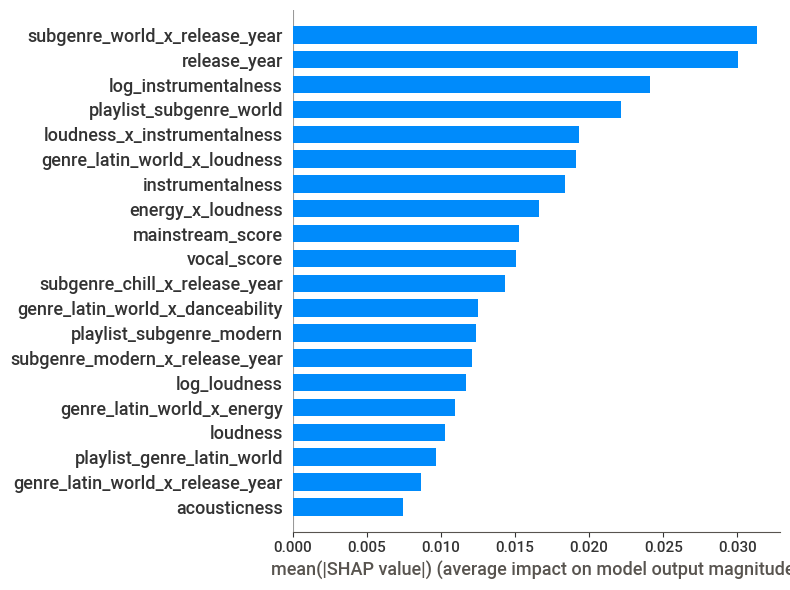

In [70]:
# Random Forest SHAP values on validation set
rf_explainer = shap.TreeExplainer(rf_model)
rf_shap_vals = rf_explainer.shap_values(X_val)

# handle all shape cases: list, 3D array, or already 2D
if isinstance(rf_shap_vals, list):
    rf_shap_vals = rf_shap_vals[1]
elif rf_shap_vals.ndim == 3:
    rf_shap_vals = rf_shap_vals[:, :, 1]

# confirm 2D
assert rf_shap_vals.ndim == 2, f"Expected 2D SHAP array, got shape {rf_shap_vals.shape}"

# global feature importance bar plot
shap.summary_plot(
    rf_shap_vals,
    X_val,
    feature_names=X_val.columns.tolist(),
    plot_type="bar",
    plot_size=(8, 6)
)

# top 10 features by mean absolute SHAP value
rf_shap_importance = pd.DataFrame({
    'feature': X_val.columns.tolist(),
    'shap_mean_abs': np.abs(rf_shap_vals).mean(axis=0)
}).sort_values('shap_mean_abs', ascending=False)

/Users/donyabehroozi/Documents/gsb545/GSB-545/tf_env/lib/python3.13/site-packages/shap/explainers/_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


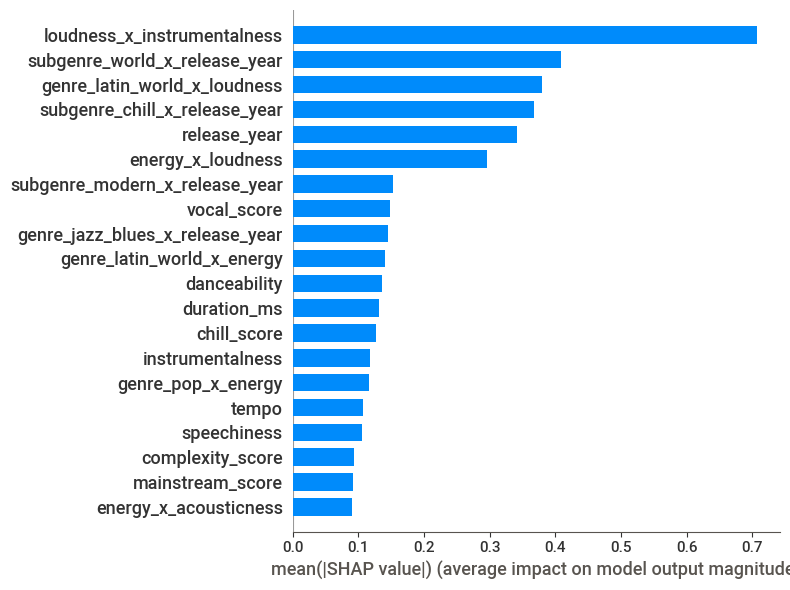

In [71]:
# LGBM Forest SHAP values on validation set
lgbm_explainer = shap.TreeExplainer(lgbm_model)
lgbm_shap_vals = lgbm_explainer.shap_values(X_val)

# handle all shape cases: list, 3D array, or already 2D
if isinstance(lgbm_shap_vals, list):
    lgbm_shap_vals = lgbm_shap_vals[1]
elif lgbm_shap_vals.ndim == 3:
    lgbm_shap_vals = lgbm_shap_vals[:, :, 1]

# confirm 2D
assert lgbm_shap_vals.ndim == 2, f"Expected 2D SHAP array, got shape {lgbm_shap_vals.shape}"

# global feature importance bar plot
shap.summary_plot(
    lgbm_shap_vals,
    X_val,
    feature_names=X_val.columns.tolist(),
    plot_type="bar",
    plot_size=(8, 6)
)

# top 10 features by mean absolute SHAP value
lgbm_shap_importance = pd.DataFrame({
    'feature': X_val.columns.tolist(),
    'shap_mean_abs': np.abs(lgbm_shap_vals).mean(axis=0)
}).sort_values('shap_mean_abs', ascending=False)

In [75]:
# Average rankings of feature importance, permutation importance, and SHAP values for Random Forest model
rf_feat_df = pd.DataFrame({
    "feature": X_train.columns.tolist(),
    "feat_importance": rf_model.feature_importances_
})

# rank feature importance and permutation importance results
rf_feat_df["rank_feat"] = rf_feat_df["feat_importance"].rank(ascending=False)
rf_perm_df["rank_perm"] = rf_perm_df["importance_mean"].rank(ascending=False)

# rank SHAP importance
rf_shap_importance["rank_shap"] = rf_shap_importance["shap_mean_abs"].rank(ascending=False)

# merge all three
rf_combined = (
    rf_feat_df
    .merge(rf_perm_df[["feature", "importance_mean", "rank_perm"]], on="feature")
    .merge(rf_shap_importance[["feature", "shap_mean_abs", "rank_shap"]], on="feature")
)

# average ranks across all three methods
rf_combined["rank_avg"] = (
    rf_combined["rank_feat"] +
    rf_combined["rank_perm"] +
    rf_combined["rank_shap"]
) / 3

# sort and display top 20 features
rf_combined = rf_combined.sort_values("rank_avg")
rf_top_features = rf_combined.head(20)
rf_top_features

,feature,feat_importance,rank_feat,importance_mean,rank_perm,shap_mean_abs,rank_shap,rank_avg
13,release_year,0.042005,1.0,0.011388,2.0,0.030019,2.0,1.666667
74,subgenre_world_x_release_year,0.029143,7.0,0.018023,1.0,0.031313,1.0,3.000000
78,log_instrumentalness,0.036855,3.0,0.003459,9.0,0.024110,3.0,5.000000
32,loudness_x_instrumentalness,0.028187,8.0,0.002676,10.0,0.019301,5.0,7.666667
66,subgenre_chill_x_release_year,0.023125,10.0,0.004589,5.0,0.014298,11.0,8.666667
29,playlist_subgenre_world,0.018963,22.0,0.006914,3.0,0.022125,4.0,9.666667
75,log_loudness,0.025734,9.0,0.001273,19.0,0.011678,15.0,14.333333
31,energy_x_loudness,0.032316,5.0,0.000709,34.0,0.016595,8.0,15.666667
71,subgenre_modern_x_release_year,0.014916,31.0,0.004570,6.0,0.012123,14.0,17.000000
50,genre_latin_world_x_loudness,0.021211,15.0,0.000883,31.0,0.019133,6.0,17.333333


In [76]:
# Average rankings of feature importance, permutation importance, and SHAP values for LGBM model
lgbm_feat_df = pd.DataFrame({
    "feature": X_train.columns.tolist(),
    "feat_importance": lgbm_model.feature_importances_
})

# rank feature importance
lgbm_feat_df["rank_feat"] = lgbm_feat_df["feat_importance"].rank(ascending=False)

# rank permutation importance
lgbm_perm_df["rank_perm"] = lgbm_perm_df["importance_mean"].rank(ascending=False)

# rank SHAP importance
lgbm_shap_importance["rank_shap"] = lgbm_shap_importance["shap_mean_abs"].rank(ascending=False)

# merge all three
lgbm_combined = (
    lgbm_feat_df
    .merge(lgbm_perm_df[["feature", "importance_mean", "rank_perm"]], on="feature")
    .merge(lgbm_shap_importance[["feature", "shap_mean_abs", "rank_shap"]], on="feature")
)

# average ranks across all three methods
lgbm_combined["rank_avg"] = (
    lgbm_combined["rank_feat"] +
    lgbm_combined["rank_perm"] +
    lgbm_combined["rank_shap"]
) / 3

# sort and display top 20 features
lgbm_combined = lgbm_combined.sort_values("rank_avg")
lgbm_top_features = lgbm_combined.head(20)
lgbm_top_features

,feature,feat_importance,rank_feat,importance_mean,rank_perm,shap_mean_abs,rank_shap,rank_avg
13,release_year,161,2.0,0.038761,2.0,0.341309,5.0,3.000000
31,energy_x_loudness,182,1.0,0.005668,10.0,0.295888,6.0,5.666667
32,loudness_x_instrumentalness,64,17.5,0.043921,1.0,0.706789,1.0,6.500000
50,genre_latin_world_x_loudness,71,15.0,0.029268,4.0,0.379482,3.0,7.333333
66,subgenre_chill_x_release_year,63,19.5,0.019713,5.0,0.367401,4.0,9.500000
2,danceability,120,6.0,0.003825,13.0,0.136597,11.0,10.000000
1,tempo,144,3.0,0.003975,12.0,0.107539,16.0,10.333333
74,subgenre_world_x_release_year,38,27.0,0.032949,3.0,0.408656,2.0,10.666667
52,genre_latin_world_x_energy,54,22.0,0.006709,9.0,0.140582,10.0,13.666667
71,subgenre_modern_x_release_year,37,28.0,0.009365,7.0,0.153394,7.0,14.000000


In [77]:
#define reduced feature set for Random Forest and LGBM models

#Random forest reduced feature set (top 20 features)
X_train_rf_20 = X_train[rf_top_features["feature"]]
X_val_rf_20 = X_val[rf_top_features["feature"]]

#XGBoost reduced feature set (top 20 features)
X_train_lgbm_20 = X_train[lgbm_top_features["feature"]]
X_val_lgbm_20 = X_val[lgbm_top_features["feature"]]

In [79]:
# run baseline models with reduced feature set - Random Forest

cv_scores_rf = cross_val_score(rf_model, X_train_rf_20, y_train, cv=cv, scoring="roc_auc", n_jobs=-1)
print(cv_scores_rf)
print(cv_scores_rf.mean())
print(cv_scores_rf.std())

rf_model.fit(X_train_rf_20, y_train)

y_proba_rf_reduced = rf_model.predict_proba(X_val_rf_20)[:,1]
print("Random Forest Baseline ROC AUC (Reduced engineered feature set):", roc_auc_score(y_val, y_proba_rf_reduced))
print(classification_report(y_val, rf_model.predict(X_val_rf_20)))

[0.87906977 0.8738877  0.89126704 0.88971808
 0.87907108]
0.8826027341231703
0.006732081037991582
Random Forest Baseline ROC AUC (Reduced engineered feature set): 0.8868566379500773
              precision    recall  f1-score   support

           0       0.85      0.92      0.88       503
           1       0.82      0.69      0.75       270

    accuracy                           0.84       773
   macro avg       0.83      0.80      0.81       773
weighted avg       0.84      0.84      0.83       773



In [81]:
# run baseline models with reduced feature set - LGBM

cv_scores_lgbm = cross_val_score(lgbm_model, X_train_lgbm_20, y_train, cv=cv, scoring="roc_auc", n_jobs=-1)
print(cv_scores_lgbm)
print(cv_scores_lgbm.mean())
print(cv_scores_lgbm.std())

lgbm_model.fit(X_train_lgbm_20, y_train)

y_proba_lgbm_reduced = lgbm_model.predict_proba(X_val_lgbm_20)[:,1]
print("LightGBM Baseline ROC AUC (Reduced engineered feature set):", roc_auc_score(y_val, y_proba_lgbm_reduced))
print(classification_report(y_val, lgbm_model.predict(X_val_lgbm_20)))

[0.88995903 0.88869525 0.90193132 0.89995048
 0.88583702]
0.8932746184590116
0.00643097442314512
LightGBM Baseline ROC AUC (Reduced engineered feature set): 0.8910389514763273
              precision    recall  f1-score   support

           0       0.87      0.84      0.86       503
           1       0.72      0.77      0.74       270

    accuracy                           0.82       773
   macro avg       0.80      0.80      0.80       773
weighted avg       0.82      0.82      0.82       773



In [28]:
#LASSO feature selection for logistic regression

lr_model_lasso = LogisticRegression(
    l1_ratio=1.0,
    solver='saga',
    class_weight='balanced',
    max_iter=2000,
    random_state=321
)

#cross validation
cv_scores_lr_lasso = cross_val_score(lr_model_lasso, X_train_scaled, y_train, cv=cv, scoring="roc_auc", n_jobs=-1)
print(cv_scores_lr_lasso)
print(cv_scores_lr_lasso.mean())
print(cv_scores_lr_lasso.std())

lr_model_lasso.fit(X_train_scaled, y_train)

#evaluate final model performance on held out test set
y_proba_lr_lasso = lr_model_lasso.predict_proba(X_val_scaled)[:, 1]
print("Logistic Regression ROC AUC (LASSO feature selection):", roc_auc_score(y_val, y_proba_lr_lasso))
print(classification_report(y_val, lr_model_lasso.predict(X_val_scaled)))

[0.84064285 0.84198742 0.86525129 0.86077137 0.83242353]
0.8482152935808047
0.012596732807459791
Logistic Regression ROC AUC (LASSO feature selection): 0.8386716736617333
              precision    recall  f1-score   support

           0       0.85      0.74      0.79       503
           1       0.61      0.75      0.67       270

    accuracy                           0.74       773
   macro avg       0.73      0.74      0.73       773
weighted avg       0.76      0.74      0.75       773



In [29]:
#check features kept and eliminated after lasso
coefs = lr_model_lasso.coef_[0]

lasso_coefs = pd.DataFrame({
    'feature': X_train_scaled.columns.tolist(),
    'coefficient': coefs
}).sort_values('coefficient', key=abs, ascending=False)

# all features
with pd.option_context('display.max_rows', None):
    display(lasso_coefs)

,feature,coefficient
13,release_year,-4.377079
3,loudness,2.961347
50,genre_latin_world_x_loudness,2.889503
41,genre_hip-hop_rnb_x_release_year,2.835040
31,energy_x_loudness,2.228459
58,genre_rock_metal_x_loudness,-2.213791
8,instrumentalness,-2.076361
2,danceability,1.527397
35,genre_classical_folk_x_danceability,1.449600
44,genre_hip-hop_rnb_x_energy,-1.334290


In [ ]:
# Naive bayes feature selection (mutual information)
selector_nb = SelectKBest(mutual_info_classif, k=20)
selector_nb.fit(X_train, y_train)

# get selected feature names
nb_selected_features = X_train.columns[selector_nb.get_support()].tolist()
print(f"Selected {len(nb_selected_features)} features for Naive Bayes:")
print(nb_selected_features)

# create reduced datasets
X_train_nb_20 = X_train[nb_selected_features]
X_val_nb_20 = X_val[nb_selected_features]

Selected 20 features for Naive Bayes:
['energy', 'loudness', 'instrumentalness', 'duration_ms', 'acousticness', 'release_year', 'energy_x_loudness', 'loudness_x_instrumentalness', 'genre_electronic_x_loudness', 'genre_pop_x_release_year', 'genre_rock_metal_x_release_year', 'subgenre_chill_x_release_year', 'subgenre_classic_x_release_year', 'log_loudness', 'log_instrumentalness', 'log_acousticness', 'energy_sq', 'chill_score', 'mainstream_score', 'vocal_score']


In [ ]:
# run baseline models with reduced feature set - Naive Bayes 
nb_model = GaussianNB()
nb_model.fit(X_train_nb_20, y_train)
y_proba_nb_reduced = nb_model.predict_proba(X_val_nb_20)[:, 1]
y_pred_nb = nb_model.predict(X_val_nb_20)

print("Naive Bayes ROC AUC (Reduced feature engineered dataset):", roc_auc_score(y_val, y_proba_nb_reduced))
print(classification_report(y_val, y_pred_nb))

Naive Bayed ROC AUC (Reduced feature engineered dataset): 0.7226787423606509
              precision    recall  f1-score   support

           0       0.76      0.65      0.70       503
           1       0.49      0.63      0.55       270

    accuracy                           0.64       773
   macro avg       0.63      0.64      0.63       773
weighted avg       0.67      0.64      0.65       773



In [100]:
# MLP feature selection: SHAP

mlp_explainer = shap.GradientExplainer(model, X_train_scaled.values[:100])
mlp_shap_vals = mlp_explainer.shap_values(X_val_scaled.values[:100])

shap_arr = mlp_shap_vals.squeeze(axis=-1)
mlp_shap_importance = pd.DataFrame({
    'feature': list(X_val_scaled.columns),
    'shap_mean_abs': list(np.abs(shap_arr).mean(axis=0))
}).sort_values('shap_mean_abs', ascending=False)

# keep top 20
mlp_selected_features = mlp_shap_importance.head(20)['feature'].tolist()
X_train_mlp_20 = X_train_scaled[mlp_selected_features]
X_val_mlp_20 = X_val_scaled[mlp_selected_features]

/Users/donyabehroozi/Documents/gsb545/GSB-545/tf_env/lib/python3.13/site-packages/keras/src/models/functional.py:258: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor
Received: inputs=['Tensor(shape=(100, 87))']
  warnings.warn(msg)
/Users/donyabehroozi/Documents/gsb545/GSB-545/tf_env/lib/python3.13/site-packages/keras/src/models/functional.py:258: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor
Received: inputs=['Tensor(shape=(50, 87))']
  warnings.warn(msg)


<positron-console-cell-103>:2: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.


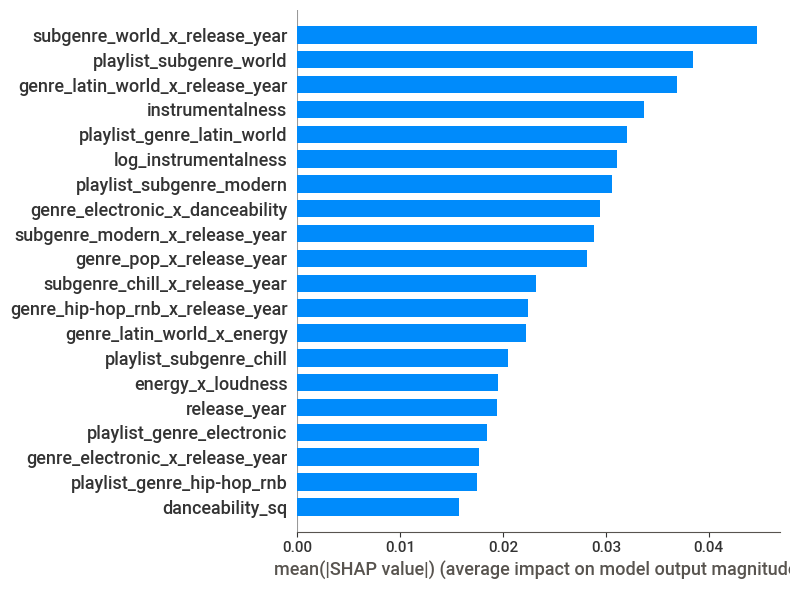

In [ ]:
# MLP SHAP visual
shap.summary_plot(
    shap_arr,
    X_val_scaled.values[:100],
    feature_names=X_val_scaled.columns.tolist(),
    plot_type="bar",
    plot_size=(8, 6)
)

In [105]:
# run baseline models with reduced feature set - MLP
tf.random.set_seed(321)

input_dim = X_train_mlp_20.shape[1]
inputs = keras.Input(shape=(input_dim,))
x = layers.Dense(64, activation='relu')(inputs)
x = layers.Dense(32, activation='relu')(x)
outputs = layers.Dense(1, activation='sigmoid')(x)
model = keras.Model(inputs=inputs, outputs=outputs, name="spotify_popularity_mlp_reduced")

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=[keras.metrics.AUC(name='auc')]
)

class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(enumerate(class_weights))

history = model.fit(
    X_train_mlp_20, y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_val_mlp_20, y_val),
    class_weight=class_weight_dict,
    verbose=1
)

y_proba_mlp_reduced = model.predict(X_val_mlp_20).flatten()
y_pred_mlp_reduced = (y_proba_mlp_reduced > 0.5).astype(int)
print("Keras MLP ROC AUC (Reduced feature set):", roc_auc_score(y_val, y_proba_mlp_reduced))
print(classification_report(y_val, y_pred_mlp_reduced, zero_division=0))

Epoch 1/20
97/97 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - auc: 0.7745 - loss: 0.5825 - val_auc: 0.8112 - val_loss: 0.5333
Epoch 2/20
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 575us/step - auc: 0.8369 - loss: 0.4994 - val_auc: 0.8279 - val_loss: 0.5099
Epoch 3/20
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 562us/step - auc: 0.8488 - loss: 0.4817 - val_auc: 0.8342 - val_loss: 0.4995
Epoch 4/20
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 562us/step - auc: 0.8548 - loss: 0.4721 - val_auc: 0.8377 - val_loss: 0.4927
Epoch 5/20
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 544us/step - auc: 0.8588 - loss: 0.4658 - val_auc: 0.8399 - val_loss: 0.4886
Epoch 6/20
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 551us/step - auc: 0.8616 - loss: 0.4612 - val_auc: 0.8421 - val_loss: 0.4847
Epoch 7/20
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 550us/step - auc: 0.8637 - loss: 0.4575 - val_auc: 0.8443 - val_loss: 0.4807
Epoch 8/20
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 533us/step - auc: 0.8657 - loss: 0.4544 - val_auc: 0.8464 - val_loss: 0.4770
Epoch 9/20
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 550us/step - auc:

# Model tuning with full or feature selected engineered dataset

In [ ]:
#Random Forest model tuning
def objective_rf(trial):
    clf = RandomForestClassifier(
        n_estimators=trial.suggest_int('n_estimators', 100, 1000),
        max_depth=trial.suggest_int('max_depth', 3, 20),
        min_samples_split=trial.suggest_int('min_samples_split', 2, 20),
        min_samples_leaf=trial.suggest_int('min_samples_leaf', 1, 10),
        max_features=trial.suggest_categorical('max_features', ['sqrt', 'log2', 0.5]),
        class_weight='balanced',
        random_state=321,
        n_jobs=-1
    )
    return cross_val_score(clf, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1).mean()

study_rf = optuna.create_study(direction='maximize')
study_rf.optimize(objective_rf, n_trials=50)

#define best model
best_rf = RandomForestClassifier(
    class_weight='balanced',
    random_state=321,
    n_jobs=-1,
    **study_rf.best_params
)

#make predictions using best model and display results
best_rf.fit(X_train, y_train)
y_proba_rf = best_rf.predict_proba(X_val)[:, 1]
y_pred_rf = best_rf.predict(X_val)

print("=== Random Forest Results (Full engineered feature set) ===")
print(f"ROC AUC Score: {roc_auc_score(y_val, y_proba_rf):.4f}")
print(classification_report(y_val, y_pred_rf))

[I 2026-05-24 09:42:30,085] A new study created in memory with name: no-name-7dad96bb-e3d2-4027-adee-eed772362a2a
[I 2026-05-24 09:42:32,444] Trial 0 finished with value: 0.8952055910339791 and parameters: {'n_estimators': 360, 'max_depth': 17, 'min_samples_split': 2, 'min_samples_leaf': 9, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.8952055910339791.
[I 2026-05-24 09:42:38,042] Trial 1 finished with value: 0.8972368449300742 and parameters: {'n_estimators': 640, 'max_depth': 17, 'min_samples_split': 16, 'min_samples_leaf': 7, 'max_features': 0.5}. Best is trial 1 with value: 0.8972368449300742.
[I 2026-05-24 09:42:41,344] Trial 2 finished with value: 0.8987223256360503 and parameters: {'n_estimators': 319, 'max_depth': 18, 'min_samples_split': 4, 'min_samples_leaf': 2, 'max_features': 0.5}. Best is trial 2 with value: 0.8987223256360503.
[I 2026-05-24 09:42:51,063] Trial 3 finished with value: 0.8950631891931395 and parameters: {'n_estimators': 927, 'max_depth': 18, 'min_sa

=== Random Forest Results ===
ROC AUC Score: 0.9063
              precision    recall  f1-score   support

           0       0.87      0.92      0.90       503
           1       0.83      0.76      0.79       270

    accuracy                           0.86       773
   macro avg       0.85      0.84      0.84       773
weighted avg       0.86      0.86      0.86       773



In [25]:
# LightGBM model tuning
def objective_lgbm(trial):
    clf = LGBMClassifier(
        n_estimators=trial.suggest_int('n_estimators', 100, 1000),
        max_depth=trial.suggest_int('max_depth', 3, 20),
        learning_rate=trial.suggest_float('learning_rate', 1e-3, 0.3, log=True),
        num_leaves=trial.suggest_int('num_leaves', 20, 300),
        min_child_samples=trial.suggest_int('min_child_samples', 5, 100),
        subsample=trial.suggest_float('subsample', 0.5, 1.0),
        colsample_bytree=trial.suggest_float('colsample_bytree', 0.5, 1.0),
        reg_alpha=trial.suggest_float('reg_alpha', 1e-8, 10, log=True),
        reg_lambda=trial.suggest_float('reg_lambda', 1e-8, 10, log=True),
        class_weight='balanced',
        random_state=321,
        n_jobs=-1,
        verbose=-1
    )
    return cross_val_score(clf, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1).mean()

study_lgbm = optuna.create_study(direction='maximize')
study_lgbm.optimize(objective_lgbm, n_trials=50)

# Define best model
best_lgbm = LGBMClassifier(
    class_weight='balanced',
    random_state=321,
    n_jobs=-1,
    verbose=-1,
    **study_lgbm.best_params
)

# Make predictions using best model and display results
best_lgbm.fit(X_train, y_train)
y_proba_lgbm = best_lgbm.predict_proba(X_val)[:, 1]
y_pred_lgbm = best_lgbm.predict(X_val)

print("=== LightGBM Results (Full engineered feature set) ===")
print(f"ROC AUC Score: {roc_auc_score(y_val, y_proba_lgbm):.4f}")
print(classification_report(y_val, y_pred_lgbm))

[I 2026-05-24 09:47:11,528] A new study created in memory with name: no-name-5ed550df-e5d9-44c0-8513-a43bb70b25d7
[I 2026-05-24 09:47:22,122] Trial 0 finished with value: 0.9072291726033519 and parameters: {'n_estimators': 798, 'max_depth': 11, 'learning_rate': 0.009597739671903643, 'num_leaves': 27, 'min_child_samples': 26, 'subsample': 0.9127201126312536, 'colsample_bytree': 0.5409149760441114, 'reg_alpha': 0.030704462689314115, 'reg_lambda': 1.9092978748988235e-05}. Best is trial 0 with value: 0.9072291726033519.
[I 2026-05-24 09:47:24,954] Trial 1 finished with value: 0.9018742676005779 and parameters: {'n_estimators': 468, 'max_depth': 5, 'learning_rate': 0.07094157049372252, 'num_leaves': 208, 'min_child_samples': 51, 'subsample': 0.818187122223555, 'colsample_bytree': 0.807470715031709, 'reg_alpha': 3.185373337473299e-07, 'reg_lambda': 1.807481166588699e-06}. Best is trial 0 with value: 0.9072291726033519.
[I 2026-05-24 09:47:31,392] Trial 2 finished with value: 0.90072225555219

=== LightGBM Results (Full engineered feature set) ===
ROC AUC Score: 0.9090
              precision    recall  f1-score   support

           0       0.88      0.90      0.89       503
           1       0.81      0.78      0.79       270

    accuracy                           0.86       773
   macro avg       0.85      0.84      0.84       773
weighted avg       0.86      0.86      0.86       773



In [31]:
# Logistic Regression model tuning on reduced feature set

lasso_kept = lasso_coefs[lasso_coefs['coefficient'] != 0]
X_train_lr_reduced = X_train_scaled[lasso_kept['feature'].tolist()]
X_val_lr_reduced = X_val_scaled[lasso_kept['feature'].tolist()]

def objective_lr(trial):
    clf = LogisticRegression(
        C=trial.suggest_float('C', 1e-4, 10, log=True),
        l1_ratio=trial.suggest_float('l1_ratio', 0.0, 1.0),
        solver='saga',
        max_iter=1000,
        class_weight='balanced',
        random_state=321
    )
    return cross_val_score(clf, X_train_lr_reduced, y_train, cv=cv, scoring='roc_auc', n_jobs=-1).mean()

study_lr = optuna.create_study(direction='maximize')
study_lr.optimize(objective_lr, n_trials=50)

# Define best model
best_lr = LogisticRegression(
    solver='saga',
    max_iter=1000,
    class_weight='balanced',
    random_state=321,
    **study_lr.best_params
)

# Make predictions using best model and display results
best_lr.fit(X_train_lr_reduced, y_train)
y_proba_lr = best_lr.predict_proba(X_val_lr_reduced)[:, 1]
y_pred_lr = best_lr.predict(X_val_lr_reduced)

print("=== Logistic Regression Results (Reduced feature set) ===")
print(f"ROC AUC Score: {roc_auc_score(y_val, y_proba_lr):.4f}")
print(classification_report(y_val, y_pred_lr))

[I 2026-05-24 10:05:26,150] A new study created in memory with name: no-name-094590cb-9533-43b1-a2fb-5449973d7650
[I 2026-05-24 10:05:26,264] Trial 0 finished with value: 0.8076155185785858 and parameters: {'C': 0.00915810394945287, 'l1_ratio': 0.22332429746576465}. Best is trial 0 with value: 0.8076155185785858.
[I 2026-05-24 10:05:26,314] Trial 1 finished with value: 0.8072888926403051 and parameters: {'C': 0.028644357900998625, 'l1_ratio': 0.9258710508958151}. Best is trial 0 with value: 0.8076155185785858.
[I 2026-05-24 10:05:26,367] Trial 2 finished with value: 0.5 and parameters: {'C': 0.0033841065861162714, 'l1_ratio': 0.7186376617154814}. Best is trial 0 with value: 0.8076155185785858.
[I 2026-05-24 10:05:26,704] Trial 3 finished with value: 0.8514993926331649 and parameters: {'C': 6.508015809197085, 'l1_ratio': 0.3624946289334844}. Best is trial 3 with value: 0.8514993926331649.
[I 2026-05-24 10:05:26,826] Trial 4 finished with value: 0.8492636323493852 and parameters: {'C': 0

=== Logistic Regression Results (Reduced feature set) ===
ROC AUC Score: 0.8414
              precision    recall  f1-score   support

           0       0.85      0.74      0.79       503
           1       0.61      0.75      0.67       270

    accuracy                           0.75       773
   macro avg       0.73      0.75      0.73       773
weighted avg       0.77      0.75      0.75       773



In [32]:
# Naive Bayes (no tuning because there are no useful/meaningful hyperparameters)
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)
y_proba_nb = nb_model.predict_proba(X_val)[:, 1]
y_pred_nb = nb_model.predict(X_val)

print("=== Naive Bayes Results (Full engineered feature set) ===")
print(f"ROC AUC Score: {roc_auc_score(y_val, y_proba_nb):.4f}")
print(classification_report(y_val, y_pred_nb))

=== Naive Bayes Results (Full engineered feature set) ===
ROC AUC Score: 0.7762
              precision    recall  f1-score   support

           0       0.85      0.61      0.71       503
           1       0.52      0.81      0.64       270

    accuracy                           0.68       773
   macro avg       0.69      0.71      0.67       773
weighted avg       0.74      0.68      0.68       773



In [34]:
# MLP model tuning
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(enumerate(class_weights))

def objective_mlp(trial):
    tf.random.set_seed(321)
    input_dim = X_train_scaled.shape[1]
    num_layers = trial.suggest_int('num_layers', 1, 4)

    inputs = keras.Input(shape=(input_dim,))
    x = inputs
    for i in range(num_layers):
        units = trial.suggest_int(f'num_units_layer_{i+1}', 16, 256)
        x = layers.Dense(units, activation='relu')(x)
        dropout_rate = trial.suggest_float(f'dropout_layer_{i+1}', 0.0, 0.5)
        x = layers.Dropout(dropout_rate)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)
    clf = keras.Model(inputs=inputs, outputs=outputs)

    clf.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=trial.suggest_float('learning_rate', 1e-4, 1e-2, log=True)
        ),
        loss='binary_crossentropy',
        metrics=[keras.metrics.AUC(name='auc')]
    )
    clf.fit(
        X_train_scaled, y_train,
        epochs=20,
        batch_size=trial.suggest_categorical('batch_size', [32, 64, 128]),
        validation_data=(X_val_scaled, y_val),
        class_weight=class_weight_dict,
        verbose=0,
        callbacks=[keras.callbacks.EarlyStopping(
            monitor='val_auc', patience=5, restore_best_weights=True, mode='max')]
    )
    y_proba = clf.predict(X_val_scaled).flatten()
    return roc_auc_score(y_val, y_proba)

study_mlp = optuna.create_study(direction='maximize')
study_mlp.optimize(objective_mlp, n_trials=50)

# Define best model
tf.random.set_seed(321)
best_params_mlp = study_mlp.best_params
num_layers = best_params_mlp['num_layers']
learning_rate = best_params_mlp['learning_rate']
batch_size = best_params_mlp['batch_size']

input_dim = X_train_scaled.shape[1]
inputs = keras.Input(shape=(input_dim,))
x = inputs
for i in range(num_layers):
    units = best_params_mlp[f'num_units_layer_{i+1}']
    x = layers.Dense(units, activation='relu')(x)
    dropout_rate = best_params_mlp[f'dropout_layer_{i+1}']
    x = layers.Dropout(dropout_rate)(x)
outputs = layers.Dense(1, activation='sigmoid')(x)
best_mlp = keras.Model(inputs=inputs, outputs=outputs)

best_mlp.compile(
    optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
    loss='binary_crossentropy',
    metrics=[keras.metrics.AUC(name='auc')]
)

# Make predictions using best model and display results
best_mlp.fit(
    X_train_scaled, y_train,
    epochs=20,
    batch_size=batch_size,
    validation_data=(X_val_scaled, y_val),
    class_weight=class_weight_dict,
    verbose=1,
    callbacks=[keras.callbacks.EarlyStopping(
        monitor='val_auc', patience=5, restore_best_weights=True, mode='max')]
)
y_proba_mlp = best_mlp.predict(X_val_scaled).flatten()
y_pred_mlp = (y_proba_mlp > 0.5).astype(int)

print("=== MLP Results ===")
print(f"ROC AUC Score: {roc_auc_score(y_val, y_proba_mlp):.4f}")
print(classification_report(y_val, y_pred_mlp, zero_division=0))

[I 2026-05-24 10:09:54,835] A new study created in memory with name: no-name-4e655a38-96c0-43a4-a2e9-24befba8fce8


25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


[I 2026-05-24 10:09:57,340] Trial 0 finished with value: 0.8883440100139902 and parameters: {'num_layers': 3, 'num_units_layer_1': 248, 'dropout_layer_1': 0.060202225925378605, 'num_units_layer_2': 113, 'dropout_layer_2': 0.16222217882417916, 'num_units_layer_3': 76, 'dropout_layer_3': 0.31143746417038704, 'learning_rate': 0.0005366917056894589, 'batch_size': 64}. Best is trial 0 with value: 0.8883440100139902.


25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 841us/step


[I 2026-05-24 10:09:58,679] Trial 1 finished with value: 0.8755062219276931 and parameters: {'num_layers': 2, 'num_units_layer_1': 42, 'dropout_layer_1': 0.33346814098201244, 'num_units_layer_2': 135, 'dropout_layer_2': 0.2623396901156326, 'learning_rate': 0.00678033536494047, 'batch_size': 128}. Best is trial 0 with value: 0.8883440100139902.


...

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


[I 2026-05-24 10:11:37,999] Trial 48 finished with value: 0.8519917531845962 and parameters: {'num_layers': 2, 'num_units_layer_1': 213, 'dropout_layer_1': 0.1786787343441484, 'num_units_layer_2': 256, 'dropout_layer_2': 0.09943406402769224, 'learning_rate': 0.00010826646568207891, 'batch_size': 128}. Best is trial 33 with value: 0.8969148074515868.


25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


[I 2026-05-24 10:11:39,808] Trial 49 finished with value: 0.836956041528606 and parameters: {'num_layers': 2, 'num_units_layer_1': 28, 'dropout_layer_1': 0.13165549192763018, 'num_units_layer_2': 212, 'dropout_layer_2': 0.0667537173710598, 'learning_rate': 0.0003326488646766828, 'batch_size': 128}. Best is trial 33 with value: 0.8969148074515868.


Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - auc: 0.7541 - loss: 0.5863 - val_auc: 0.8124 - val_loss: 0.5297
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - auc: 0.8336 - loss: 0.5018 - val_auc: 0.8419 - val_loss: 0.5314
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - auc: 0.8567 - loss: 0.4693 - val_auc: 0.8572 - val_loss: 0.4650
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - auc: 0.8753 - loss: 0.4409 - val_auc: 0.8698 - val_loss: 0.4435
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - auc: 0.8805 - loss: 0.4309 - val_auc: 0.8753 - val_loss: 0.4367
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - auc: 0.8864 - loss: 0.4199 - val_auc: 0.8803 - val_loss: 0.4254
Epoch 7/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - auc: 0.8919 - loss: 0.4113 - val_auc: 0.8836 - val_loss: 0.4260
Epoch 8/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - auc: 0.8979 - loss: 0.3993 - val_auc: 0.8828 - val_loss: 0.4196
Epoch 9/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - auc: 0.8986 - loss: 

# Ensembling (probability model): Tuned Random Forest and LGBM full engineered feature set models

In [63]:
# Create ensemble model with RF baseline and tuned LGBM
print("Generating OOF predictions...")
rf_oof = cross_val_predict(best_rf, X_train, y_train, cv=cv, method='predict_proba', n_jobs=-1)
lgbm_oof = cross_val_predict(best_lgbm, X_train, y_train, cv=cv, method='predict_proba', n_jobs=-1)

# optimize ensemble weights with Optuna
def ensemble_objective(trial):
    w_rf = trial.suggest_float('w_rf', 0.0, 1.0)
    w_lgbm = trial.suggest_float('w_lgbm', 0.0, 1.0)
    total = w_rf + w_lgbm

    blended = (w_rf * rf_oof + w_lgbm * lgbm_oof) / total
    return roc_auc_score(y_train, blended[:, 1])

ensemble_study = optuna.create_study(direction='maximize')
ensemble_study.optimize(ensemble_objective, n_trials=100)

# normalize best weights to sum to 1
raw = ensemble_study.best_params
total = sum(raw.values())
w_rf = raw['w_rf'] / total
w_lgbm = raw['w_lgbm'] / total

print(f'Best weights — RF: {w_rf:.3f}, LGBM: {w_lgbm:.3f}')
print(f'Best OOF ROC AUC: {ensemble_study.best_value:.4f}')

# apply best weights to validation set
rf_val_probs = best_rf.predict_proba(X_val)
lgbm_val_probs = best_lgbm.predict_proba(X_val)

blended_val = w_rf * rf_val_probs + w_lgbm * lgbm_val_probs
ensemble_preds = (blended_val[:, 1] >= 0.5).astype(int)

print("=== Ensemble Results (Probability weighted model) ===")
print(f"ROC AUC: {roc_auc_score(y_val, blended_val[:, 1]):.4f}")
print(classification_report(y_val, ensemble_preds))

Generating OOF predictions...


[I 2026-05-24 10:49:02,472] A new study created in memory with name: no-name-c7d86891-a5d1-444d-9b08-0a409e36ab5d
[I 2026-05-24 10:49:02,535] Trial 0 finished with value: 0.9087342826159923 and parameters: {'w_rf': 0.30606088822007704, 'w_lgbm': 0.799661925367898}. Best is trial 0 with value: 0.9087342826159923.
[I 2026-05-24 10:49:02,544] Trial 1 finished with value: 0.9061694305410579 and parameters: {'w_rf': 0.757753932700575, 'w_lgbm': 0.04205767415710271}. Best is trial 0 with value: 0.9087342826159923.
[I 2026-05-24 10:49:02,550] Trial 2 finished with value: 0.9089131721728996 and parameters: {'w_rf': 0.2080540914728939, 'w_lgbm': 0.3455081206868138}. Best is trial 2 with value: 0.9089131721728996.
[I 2026-05-24 10:49:02,552] Trial 3 finished with value: 0.909010454895857 and parameters: {'w_rf': 0.40643357297331995, 'w_lgbm': 0.30100805519143237}. Best is trial 3 with value: 0.909010454895857.
[I 2026-05-24 10:49:02,555] Trial 4 finished with value: 0.9088274158389182 and parame

Best weights — RF: 0.478, LGBM: 0.522
Best OOF ROC AUC: 0.9091
=== Ensemble Results (Probability weighted model) ===
ROC AUC: 0.9089
              precision    recall  f1-score   support

           0       0.89      0.91      0.90       503
           1       0.83      0.79      0.81       270

    accuracy                           0.87       773
   macro avg       0.86      0.85      0.85       773
weighted avg       0.87      0.87      0.87       773



# Ensembling (meta-learner): Tuned random forest and LGBM models on full engineered feature set + Logistic Regression as meta learner

In [64]:
# Create ensemble model with logistic regression meta-learner
X_meta_train = np.column_stack([
    rf_oof[:, 1],
    lgbm_oof[:, 1]
])

# get validation probabilities from each model
rf_val_probs = best_rf.predict_proba(X_val)
lgbm_val_probs = best_lgbm.predict_proba(X_val)

X_meta_val = np.column_stack([
    rf_val_probs[:, 1],
    lgbm_val_probs[:, 1]
])

# fit meta learner on OOF predictions
meta_learner = LogisticRegression(
    class_weight='balanced',
    random_state=321,
    max_iter=1000
)
meta_learner.fit(X_meta_train, y_train)

# evaluate on validation set
meta_proba = meta_learner.predict_proba(X_meta_val)[:, 1]
meta_preds = meta_learner.predict(X_meta_val)

print("=== Ensemble Results (Meta Learner) ===")
print(f"ROC AUC: {roc_auc_score(y_val, meta_proba):.4f}")
print(classification_report(y_val, meta_preds))

# inspect meta learner weights
print("\nMeta learner coefficients:")
print(f"Random Forest weight: {meta_learner.coef_[0][0]:.4f}")
print(f"LGBM weight: {meta_learner.coef_[0][1]:.4f}")

=== Ensemble Results (Meta Learner) ===
ROC AUC: 0.9083
              precision    recall  f1-score   support

           0       0.90      0.88      0.89       503
           1       0.79      0.83      0.81       270

    accuracy                           0.86       773
   macro avg       0.85      0.86      0.85       773
weighted avg       0.87      0.86      0.86       773


Meta learner coefficients:
Random Forest weight: 4.3513
LGBM weight: 1.9115
